In [1]:
# ============================================================
# PS-1: TICKET INTENT CLASSIFICATION
# CELL 1 — IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import re
import string
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD TWCS DATASET
# ============================================================

DATA_PATH = "twcs.csv"

df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "tweet_id",
        "author_id",
        "inbound",
        "created_at",
        "text",
        "in_response_to_tweet_id",
        "response_tweet_id"
    ]
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2811774, 7)

Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

First 5 rows:


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [3]:
# ============================================================
# CELL 3 — FILTER INBOUND CUSTOMER MESSAGES
# ============================================================

customer_df = df[
    df["inbound"] == True
].copy()

print("Total inbound customer messages:", len(customer_df))

print("\nInbound message sample:")
display(
    customer_df[
        ["tweet_id", "text", "created_at"]
    ].head()
)

Total inbound customer messages: 1537843

Inbound message sample:


,tweet_id,text,created_at
1,2,@sprintcare and how do you propose we do that,Tue Oct 31 22:11:45 +0000 2017
2,3,@sprintcare I have sent several private messag...,Tue Oct 31 22:08:27 +0000 2017
4,5,@sprintcare I did.,Tue Oct 31 21:49:35 +0000 2017
6,8,@sprintcare is the worst customer service,Tue Oct 31 21:45:10 +0000 2017
8,12,@sprintcare You gonna magically change your co...,Tue Oct 31 22:04:47 +0000 2017


In [4]:
# ============================================================
# CELL 4 — BASIC DATA CLEANING
# ============================================================

customer_df["text"] = customer_df["text"].fillna("").astype(str)

# Remove empty messages
customer_df = customer_df[
    customer_df["text"].str.strip() != ""
].copy()

# Remove duplicate tweets
customer_df = customer_df.drop_duplicates(
    subset="tweet_id"
).reset_index(drop=True)

print("After removing empty/duplicate messages:")
print("Shape:", customer_df.shape)

print("\nMissing values:")
print(customer_df.isnull().sum())

After removing empty/duplicate messages:
Shape: (1537843, 7)

Missing values:
tweet_id                        0
author_id                       0
inbound                         0
created_at                      0
text                            0
response_tweet_id          234014
in_response_to_tweet_id    787346
dtype: int64


In [5]:
# ============================================================
# CELL 5 — CREATE MANAGEABLE PS-1 SAMPLE
# ============================================================

SAMPLE_SIZE = 150000

if len(customer_df) > SAMPLE_SIZE:
    ps1_df = customer_df.sample(
        n=SAMPLE_SIZE,
        random_state=42
    ).reset_index(drop=True)
else:
    ps1_df = customer_df.copy()

print("PS-1 dataset shape:", ps1_df.shape)

PS-1 dataset shape: (150000, 7)


In [6]:
# ============================================================
# CELL 6 — TEXT CLEANING
# ============================================================

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove @mentions
    text = re.sub(r"@\w+", " ", text)

    # Handle common contractions
    contractions = {
        "can't": "cannot",
        "won't": "will not",
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "couldn't": "could not",
        "wouldn't": "would not",
        "shouldn't": "should not",
        "i'm": "i am",
        "you're": "you are",
        "we're": "we are",
        "it's": "it is",
        "that's": "that is"
    }

    for contraction, replacement in contractions.items():
        text = text.replace(
            contraction,
            replacement
        )

    # Remove non-ASCII characters / emojis
    text = text.encode(
        "ascii",
        "ignore"
    ).decode()

    # Keep alphabetic characters and spaces
    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


ps1_df["clean_text"] = (
    ps1_df["text"]
    .apply(clean_text)
)

print("Original:")
print(ps1_df["text"].iloc[0])

print("\nCleaned:")
print(ps1_df["clean_text"].iloc[0])

Original:
@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice.

Cleaned:
basically for a chat to be opened from call log the message app should be opened running in background otherwise it takes twice


In [7]:
# ============================================================
# CELL 7 — ENGINEER INTENT LABELS
# ============================================================

BILLING_KEYWORDS = [
    "refund",
    "refunded",
    "refunds",
    "charged",
    "charge",
    "payment",
    "pay",
    "billing",
    "bill",
    "price",
    "pricing",
    "money",
    "transaction",
    "fee",
    "fees",
    "credit",
    "debit",
    "invoice",
    "overcharged",
    "charged twice",
    "double charged"
]

TECHNICAL_KEYWORDS = [
    "not working",
    "does not work",
    "doesn't work",
    "cannot login",
    "can't login",
    "error",
    "bug",
    "crash",
    "crashed",
    "broken",
    "issue",
    "problem",
    "app",
    "website",
    "site",
    "loading",
    "login",
    "log in",
    "technical",
    "glitch",
    "failed",
    "failure"
]

ACCOUNT_KEYWORDS = [
    "password",
    "forgot password",
    "reset password",
    "username",
    "account",
    "account locked",
    "locked out",
    "sign in",
    "signin",
    "login details",
    "profile",
    "change email",
    "change my email",
    "verify account",
    "verification"
]

COMPLAINT_KEYWORDS = [
    "complaint",
    "complain",
    "terrible",
    "worst",
    "horrible",
    "awful",
    "bad service",
    "poor service",
    "unacceptable",
    "disappointed",
    "disappointing",
    "angry",
    "ridiculous",
    "frustrated",
    "frustrating",
    "useless",
    "hate"
]


def assign_intent(text):

    text = str(text).lower()

    # Billing
    if any(
        keyword in text
        for keyword in BILLING_KEYWORDS
    ):
        return "Billing Issue"

    # Technical
    if any(
        keyword in text
        for keyword in TECHNICAL_KEYWORDS
    ):
        return "Technical Issue"

    # Account
    if any(
        keyword in text
        for keyword in ACCOUNT_KEYWORDS
    ):
        return "Account Management"

    # Complaint
    if any(
        keyword in text
        for keyword in COMPLAINT_KEYWORDS
    ):
        return "Complaint"

    # Default
    return "General Inquiry"


ps1_df["intent"] = (
    ps1_df["clean_text"]
    .apply(assign_intent)
)

print("Intent labeling completed.")

Intent labeling completed.


In [8]:
# ============================================================
# CELL 8 — INTENT DISTRIBUTION
# ============================================================

intent_counts = (
    ps1_df["intent"]
    .value_counts()
)

print("Intent distribution:")
display(
    intent_counts.to_frame(
        "message_count"
    )
)

print("\nIntent percentages:")
display(
    (
        ps1_df["intent"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_frame("percentage")
    )
)

Intent distribution:


,message_count
intent,
General Inquiry,100805
Technical Issue,25026
Billing Issue,16162
Complaint,5023
Account Management,2984



Intent percentages:


,percentage
intent,
General Inquiry,67.20
Technical Issue,16.68
Billing Issue,10.77
Complaint,3.35
Account Management,1.99


In [9]:
# ============================================================
# CELL 9 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Use cleaned text as input
X = ps1_df["clean_text"]

# Engineered intent labels
y = ps1_df["intent"]

# ------------------------------------------------------------
# First split:
# 80% Training
# 20% Temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Second split:
# Temporary -> 10% Validation + 10% Test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("========== DATASET SPLIT ==========")

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\n========== TRAIN DISTRIBUTION ==========")
display(
    y_train.value_counts()
    .to_frame("count")
)

print("\n========== VALIDATION DISTRIBUTION ==========")
display(
    y_val.value_counts()
    .to_frame("count")
)

print("\n========== TEST DISTRIBUTION ==========")
display(
    y_test.value_counts()
    .to_frame("count")
)

========== DATASET SPLIT ==========
Training: (120000,)
Validation: (15000,)
Test: (15000,)

========== TRAIN DISTRIBUTION ==========


,count
intent,
General Inquiry,80644
Technical Issue,20021
Billing Issue,12930
Complaint,4018
Account Management,2387



========== VALIDATION DISTRIBUTION ==========


,count
intent,
General Inquiry,10080
Technical Issue,2502
Billing Issue,1616
Complaint,503
Account Management,299



========== TEST DISTRIBUTION ==========


,count
intent,
General Inquiry,10081
Technical Issue,2503
Billing Issue,1616
Complaint,502
Account Management,298


In [10]:
# ============================================================
# CELL 10 — TF-IDF FEATURE EXTRACTION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF: Unigrams + Bigrams
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit ONLY on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("========== TF-IDF FEATURES ==========")

print("Training shape   :", X_train_tfidf.shape)
print("Validation shape :", X_val_tfidf.shape)
print("Test shape       :", X_test_tfidf.shape)

print("Vocabulary size  :", len(tfidf.vocabulary_))

print("\nMatrix type:")
print(type(X_train_tfidf))

# Calculate sparsity
total_elements = (
    X_train_tfidf.shape[0] *
    X_train_tfidf.shape[1]
)

sparsity = 100 * (
    1 - X_train_tfidf.nnz / total_elements
)

print("\nSparsity:")
print(f"{sparsity:.2f}%")

========== TF-IDF FEATURES ==========
Training shape   : (120000, 30000)
Validation shape : (15000, 30000)
Test shape       : (15000, 30000)
Vocabulary size  : 30000

Matrix type:
<class 'scipy.sparse._csr.csr_matrix'>

Sparsity:
99.93%


In [11]:
# ============================================================
# CELL 11 — BASELINE LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Train baseline classifier
# ------------------------------------------------------------

baseline_lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="liblinear",
    random_state=42
)

baseline_lr.fit(
    X_train_tfidf,
    y_train
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

y_val_pred_lr = baseline_lr.predict(X_val_tfidf)

# ------------------------------------------------------------
# Validation metrics
# ------------------------------------------------------------

accuracy_lr = accuracy_score(y_val, y_val_pred_lr)

precision_lr = precision_score(
    y_val,
    y_val_pred_lr,
    average="macro",
    zero_division=0
)

recall_lr = recall_score(
    y_val,
    y_val_pred_lr,
    average="macro",
    zero_division=0
)

f1_lr = f1_score(
    y_val,
    y_val_pred_lr,
    average="macro",
    zero_division=0
)

print("========== BASELINE LOGISTIC REGRESSION ==========")

print(f"Accuracy          : {accuracy_lr:.4f}")
print(f"Macro Precision   : {precision_lr:.4f}")
print(f"Macro Recall      : {recall_lr:.4f}")
print(f"Macro F1          : {f1_lr:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        y_val_pred_lr,
        zero_division=0
    )
)

========== BASELINE LOGISTIC REGRESSION ==========
Accuracy          : 0.9396
Macro Precision   : 0.9458
Macro Recall      : 0.8177
Macro F1          : 0.8731

========== CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.90      0.75      0.82       299
     Billing Issue       1.00      0.82      0.90      1616
         Complaint       0.94      0.66      0.78       503
   General Inquiry       0.93      1.00      0.96     10080
   Technical Issue       0.97      0.85      0.91      2502

          accuracy                           0.94     15000
         macro avg       0.95      0.82      0.87     15000
      weighted avg       0.94      0.94      0.94     15000



In [12]:
# ============================================================
# CELL 12 — LINEAR SVM CLASSIFIER
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Train Linear SVM
# ------------------------------------------------------------

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

# ------------------------------------------------------------
# Validation prediction
# ------------------------------------------------------------

y_val_pred_svm = svm_model.predict(X_val_tfidf)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy_svm = accuracy_score(
    y_val,
    y_val_pred_svm
)

precision_svm = precision_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

recall_svm = recall_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

f1_svm = f1_score(
    y_val,
    y_val_pred_svm,
    average="macro",
    zero_division=0
)

print("========== LINEAR SVM ==========")

print(f"Accuracy          : {accuracy_svm:.4f}")
print(f"Macro Precision   : {precision_svm:.4f}")
print(f"Macro Recall      : {recall_svm:.4f}")
print(f"Macro F1          : {f1_svm:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        y_val_pred_svm,
        zero_division=0
    )
)

========== LINEAR SVM ==========
Accuracy          : 0.9847
Macro Precision   : 0.9732
Macro Recall      : 0.9649
Macro F1          : 0.9687

========== CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.93      0.97      0.95       299
     Billing Issue       1.00      0.95      0.97      1616
         Complaint       0.97      0.95      0.96       503
   General Inquiry       0.98      1.00      0.99     10080
   Technical Issue       0.99      0.95      0.97      2502

          accuracy                           0.98     15000
         macro avg       0.97      0.96      0.97     15000
      weighted avg       0.98      0.98      0.98     15000



In [13]:
# ============================================================
# CELL 13 — PS-1 MODEL COMPARISON
# ============================================================

import pandas as pd

comparison_ps1 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm
    ],
    "Macro Precision": [
        precision_lr,
        precision_svm
    ],
    "Macro Recall": [
        recall_lr,
        recall_svm
    ],
    "Macro F1": [
        f1_lr,
        f1_svm
    ]
})

comparison_ps1 = comparison_ps1.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("========== PS-1 MODEL COMPARISON ==========")

display(
    comparison_ps1.round(4)
)

print("\n========== BEST MODEL ==========")

best_model_name = comparison_ps1.loc[0, "Model"]
best_f1 = comparison_ps1.loc[0, "Macro F1"]

print("Best Model :", best_model_name)
print("Best Macro F1 :", round(best_f1, 4))

========== PS-1 MODEL COMPARISON ==========


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Linear SVM,0.9847,0.9732,0.9649,0.9687
1,Logistic Regression,0.9396,0.9458,0.8177,0.8731



========== BEST MODEL ==========
Best Model : Linear SVM
Best Macro F1 : 0.9687


In [14]:
# ============================================================
# CELL 14 — SVD REPRESENTATION FOR TREE-BASED MODELS
# ============================================================

from sklearn.decomposition import TruncatedSVD

svd_ps1 = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_train_svd_ps1 = svd_ps1.fit_transform(X_train_tfidf)
X_val_svd_ps1 = svd_ps1.transform(X_val_tfidf)
X_test_svd_ps1 = svd_ps1.transform(X_test_tfidf)

print("========== SVD REPRESENTATION ==========")

print("Original TF-IDF dimensions :", X_train_tfidf.shape[1])
print("Reduced dimensions         :", X_train_svd_ps1.shape[1])

print("Training shape   :", X_train_svd_ps1.shape)
print("Validation shape :", X_val_svd_ps1.shape)
print("Test shape       :", X_test_svd_ps1.shape)

print(
    "Explained variance ratio:",
    round(svd_ps1.explained_variance_ratio_.sum(), 4)
)

========== SVD REPRESENTATION ==========
Original TF-IDF dimensions : 30000
Reduced dimensions         : 300
Training shape   : (120000, 300)
Validation shape : (15000, 300)
Test shape       : (15000, 300)
Explained variance ratio: 0.2252


In [15]:
# ============================================================
# CELL 15 — RANDOM FOREST CLASSIFIER
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

rf_ps1 = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_ps1.fit(
    X_train_svd_ps1,
    y_train
)

y_val_pred_rf = rf_ps1.predict(
    X_val_svd_ps1
)

accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

precision_rf = precision_score(
    y_val,
    y_val_pred_rf,
    average="macro",
    zero_division=0
)

recall_rf = recall_score(
    y_val,
    y_val_pred_rf,
    average="macro",
    zero_division=0
)

f1_rf = f1_score(
    y_val,
    y_val_pred_rf,
    average="macro",
    zero_division=0
)

print("\n========== RANDOM FOREST ==========")

print(f"Accuracy        : {accuracy_rf:.4f}")
print(f"Macro Precision : {precision_rf:.4f}")
print(f"Macro Recall    : {recall_rf:.4f}")
print(f"Macro F1        : {f1_rf:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        y_val_pred_rf,
        zero_division=0
    )
)

Training Random Forest...

========== RANDOM FOREST ==========
Accuracy        : 0.7711
Macro Precision : 0.8341
Macro Recall    : 0.4565
Macro F1        : 0.5274

========== CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.68      0.51      0.59       299
     Billing Issue       0.97      0.30      0.45      1616
         Complaint       0.86      0.16      0.26       503
   General Inquiry       0.76      1.00      0.86     10080
   Technical Issue       0.91      0.32      0.48      2502

          accuracy                           0.77     15000
         macro avg       0.83      0.46      0.53     15000
      weighted avg       0.81      0.77      0.73     15000



In [16]:
# ============================================================
# CELL 16 — XGBOOST CLASSIFIER
# ============================================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target labels for XGBoost
label_encoder_ps1 = LabelEncoder()

y_train_xgb = label_encoder_ps1.fit_transform(y_train)
y_val_xgb = label_encoder_ps1.transform(y_val)

xgb_ps1 = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder_ps1.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_ps1.fit(
    X_train_svd_ps1,
    y_train_xgb
)

# Validation prediction
y_val_pred_xgb_encoded = xgb_ps1.predict(
    X_val_svd_ps1
)

# Convert predictions back to original labels
y_val_pred_xgb = label_encoder_ps1.inverse_transform(
    y_val_pred_xgb_encoded.astype(int)
)

accuracy_xgb = accuracy_score(
    y_val,
    y_val_pred_xgb
)

precision_xgb = precision_score(
    y_val,
    y_val_pred_xgb,
    average="macro",
    zero_division=0
)

recall_xgb = recall_score(
    y_val,
    y_val_pred_xgb,
    average="macro",
    zero_division=0
)

f1_xgb = f1_score(
    y_val,
    y_val_pred_xgb,
    average="macro",
    zero_division=0
)

print("\n========== XGBOOST ==========")

print(f"Accuracy        : {accuracy_xgb:.4f}")
print(f"Macro Precision : {precision_xgb:.4f}")
print(f"Macro Recall    : {recall_xgb:.4f}")
print(f"Macro F1        : {f1_xgb:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        y_val_pred_xgb,
        zero_division=0
    )
)

Training XGBoost...

========== XGBOOST ==========
Accuracy        : 0.8306
Macro Precision : 0.8658
Macro Recall    : 0.5612
Macro F1        : 0.6448

========== CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.80      0.56      0.66       299
     Billing Issue       0.94      0.48      0.64      1616
         Complaint       0.88      0.22      0.35       503
   General Inquiry       0.82      0.99      0.90     10080
   Technical Issue       0.89      0.56      0.69      2502

          accuracy                           0.83     15000
         macro avg       0.87      0.56      0.64     15000
      weighted avg       0.84      0.83      0.81     15000



In [17]:
# ============================================================
# CELL 17 — COMPLETE PS-1 MODEL COMPARISON
# ============================================================

import pandas as pd

comparison_ps1 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_svm,
        accuracy_rf,
        accuracy_xgb
    ],
    "Macro Precision": [
        precision_lr,
        precision_svm,
        precision_rf,
        precision_xgb
    ],
    "Macro Recall": [
        recall_lr,
        recall_svm,
        recall_rf,
        recall_xgb
    ],
    "Macro F1": [
        f1_lr,
        f1_svm,
        f1_rf,
        f1_xgb
    ]
})

comparison_ps1 = comparison_ps1.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("========== FINAL PS-1 MODEL COMPARISON ==========")

display(
    comparison_ps1.round(4)
)

print("\n========== BEST MODEL ==========")

best_model = comparison_ps1.iloc[0]

print("Model:", best_model["Model"])
print("Macro F1:", round(best_model["Macro F1"], 4))

========== FINAL PS-1 MODEL COMPARISON ==========


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Linear SVM,0.9847,0.9732,0.9649,0.9687
1,Logistic Regression,0.9396,0.9458,0.8177,0.8731
2,XGBoost,0.8306,0.8658,0.5612,0.6448
3,Random Forest,0.7711,0.8341,0.4565,0.5274



========== BEST MODEL ==========
Model: Linear SVM
Macro F1: 0.9687


In [18]:
# ============================================================
# CELL 18 — LINEAR SVM HYPERPARAMETER TUNING
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]

svm_results = []

for C in C_values:

    print(f"Training Linear SVM with C={C}...")

    svm_temp = LinearSVC(
        C=C,
        class_weight="balanced",
        random_state=42
    )

    svm_temp.fit(
        X_train_tfidf,
        y_train
    )

    y_pred = svm_temp.predict(
        X_val_tfidf
    )

    acc = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average="macro",
        zero_division=0
    )

    svm_results.append({
        "C": C,
        "Accuracy": acc,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })


svm_tuning_results = pd.DataFrame(
    svm_results
)

svm_tuning_results = svm_tuning_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("\n========== SVM HYPERPARAMETER TUNING ==========")

display(
    svm_tuning_results.round(4)
)

best_C = svm_tuning_results.loc[0, "C"]
best_svm_f1 = svm_tuning_results.loc[0, "Macro F1"]

print("\n========== BEST SVM ==========")
print("Best C:", best_C)
print("Best Validation Macro F1:", round(best_svm_f1, 4))

Training Linear SVM with C=0.01...
Training Linear SVM with C=0.1...
Training Linear SVM with C=0.5...
Training Linear SVM with C=1.0...
Training Linear SVM with C=2.0...
Training Linear SVM with C=5.0...

========== SVM HYPERPARAMETER TUNING ==========


,C,Accuracy,Macro Precision,Macro Recall,Macro F1
0,2.00,0.9851,0.9767,0.9633,0.9698
1,1.00,0.9847,0.9732,0.9649,0.9687
2,5.00,0.9837,0.9762,0.9592,0.9675
3,0.50,0.9826,0.9677,0.9631,0.9650
4,0.10,0.9689,0.9408,0.9423,0.9398
5,0.01,0.9124,0.8603,0.8426,0.8396



========== BEST SVM ==========
Best C: 2.0
Best Validation Macro F1: 0.9698


========== FINAL TUNED LINEAR SVM ==========
Best C          : 2.0
Accuracy        : 0.9851
Macro Precision : 0.9767
Macro Recall    : 0.9633
Macro F1        : 0.9698

========== CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.95      0.96      0.95       299
     Billing Issue       1.00      0.95      0.98      1616
         Complaint       0.97      0.95      0.96       503
   General Inquiry       0.98      1.00      0.99     10080
   Technical Issue       0.99      0.96      0.97      2502

          accuracy                           0.99     15000
         macro avg       0.98      0.96      0.97     15000
      weighted avg       0.99      0.99      0.99     15000



<Figure size 800x600 with 0 Axes>

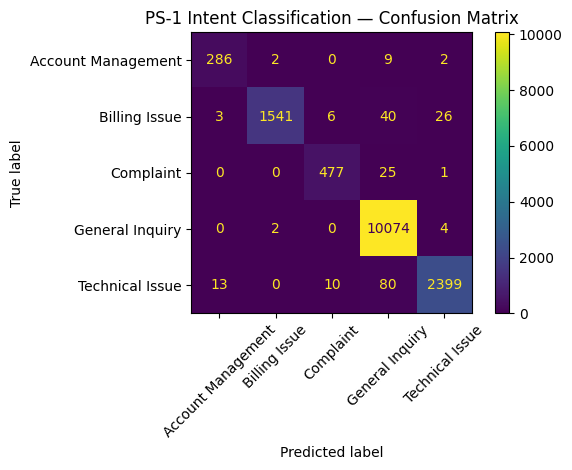

In [19]:
# ============================================================
# CELL 19 — FINAL TUNED LINEAR SVM
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Best hyperparameter from validation
best_C = 2.0

final_svm = LinearSVC(
    C=best_C,
    class_weight="balanced",
    random_state=42
)

# Train final model
final_svm.fit(
    X_train_tfidf,
    y_train
)

# Validation prediction
y_val_pred_final = final_svm.predict(
    X_val_tfidf
)

# Metrics
final_accuracy = accuracy_score(
    y_val,
    y_val_pred_final
)

final_precision = precision_score(
    y_val,
    y_val_pred_final,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_val,
    y_val_pred_final,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_val,
    y_val_pred_final,
    average="macro",
    zero_division=0
)

print("========== FINAL TUNED LINEAR SVM ==========")

print(f"Best C          : {best_C}")
print(f"Accuracy        : {final_accuracy:.4f}")
print(f"Macro Precision : {final_precision:.4f}")
print(f"Macro Recall    : {final_recall:.4f}")
print(f"Macro F1        : {final_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val,
        y_val_pred_final,
        zero_division=0
    )
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_val,
    y_val_pred_final,
    labels=final_svm.classes_
)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_svm.classes_
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("PS-1 Intent Classification — Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CELL 20 — PS-1 ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Find validation text variable
# ------------------------------------------------------------

possible_text_vars = [
    "X_val_text_raw",
    "X_val_text",
    "val_messages",
    "validation_text",
    "val_data"
]

val_text_data = None

for var_name in possible_text_vars:
    if var_name in globals():
        val_text_data = globals()[var_name]
        print("Using validation text variable:", var_name)
        break

# ------------------------------------------------------------
# If raw validation text is unavailable, create error analysis
# using actual and predicted labels only
# ------------------------------------------------------------

if val_text_data is None:

    error_df = pd.DataFrame({
        "actual": np.array(y_val),
        "predicted": np.array(y_val_pred_final)
    })

else:

    error_df = pd.DataFrame({
        "text": np.array(val_text_data),
        "actual": np.array(y_val),
        "predicted": np.array(y_val_pred_final)
    })

# ------------------------------------------------------------
# Misclassified samples
# ------------------------------------------------------------

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("\n========== PS-1 ERROR ANALYSIS ==========")

print("Total validation samples :", len(error_df))
print("Correct predictions      :", len(error_df) - len(errors))
print("Incorrect predictions    :", len(errors))

print(
    "Validation error rate    :",
    round(len(errors) / len(error_df) * 100, 2),
    "%"
)

# ------------------------------------------------------------
# Most common confusion pairs
# ------------------------------------------------------------

confusions = (
    errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("\n========== MOST COMMON INTENT CONFUSIONS ==========")

display(confusions.head(15))

# ------------------------------------------------------------
# Sample errors if text is available
# ------------------------------------------------------------

if "text" in errors.columns:

    print("\n========== SAMPLE MISCLASSIFICATIONS ==========")

    display(
        errors[
            ["actual", "predicted", "text"]
        ].head(20)
    )
else:

    print(
        "\nRaw validation text was not found, "
        "so sample messages cannot be displayed."
    )


========== PS-1 ERROR ANALYSIS ==========
Total validation samples : 15000
Correct predictions      : 14777
Incorrect predictions    : 223
Validation error rate    : 1.49 %

========== MOST COMMON INTENT CONFUSIONS ==========


,actual,predicted,count
0,Technical Issue,General Inquiry,80
1,Billing Issue,General Inquiry,40
2,Billing Issue,Technical Issue,26
3,Complaint,General Inquiry,25
4,Technical Issue,Account Management,13
5,Technical Issue,Complaint,10
6,Account Management,General Inquiry,9
7,Billing Issue,Complaint,6
8,General Inquiry,Technical Issue,4
9,Billing Issue,Account Management,3



Raw validation text was not found, so sample messages cannot be displayed.


========== FINAL PS-1 TEST PERFORMANCE ==========
Accuracy        : 0.9847
Macro Precision : 0.9763
Macro Recall    : 0.9663
Macro F1        : 0.9711

========== TEST CLASSIFICATION REPORT ==========
                    precision    recall  f1-score   support

Account Management       0.95      0.96      0.95       298
     Billing Issue       1.00      0.95      0.97      1616
         Complaint       0.97      0.96      0.97       502
   General Inquiry       0.99      1.00      0.99     10081
   Technical Issue       0.98      0.96      0.97      2503

          accuracy                           0.98     15000
         macro avg       0.98      0.97      0.97     15000
      weighted avg       0.98      0.98      0.98     15000



<Figure size 800x600 with 0 Axes>

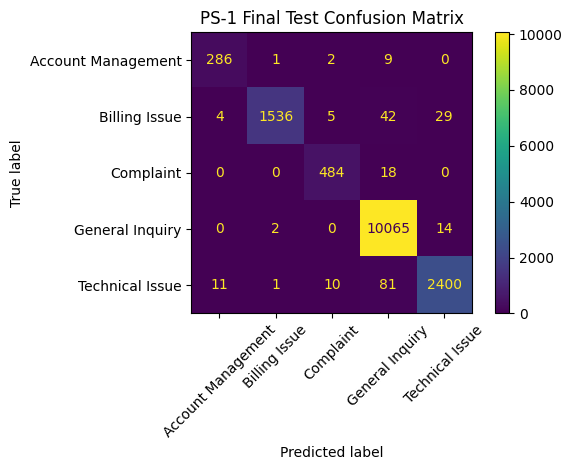

In [21]:
# ============================================================
# CELL 21 — FINAL PS-1 TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------

y_test_pred_final = final_svm.predict(
    X_test_tfidf
)

# ------------------------------------------------------------
# Test metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    y_test_pred_final
)

test_precision = precision_score(
    y_test,
    y_test_pred_final,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_final,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_final,
    average="macro",
    zero_division=0
)

print("========== FINAL PS-1 TEST PERFORMANCE ==========")

print(f"Accuracy        : {test_accuracy:.4f}")
print(f"Macro Precision : {test_precision:.4f}")
print(f"Macro Recall    : {test_recall:.4f}")
print(f"Macro F1        : {test_f1:.4f}")

print("\n========== TEST CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_test_pred_final,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Test confusion matrix
# ------------------------------------------------------------

cm_test = confusion_matrix(
    y_test,
    y_test_pred_final,
    labels=final_svm.classes_
)

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_svm.classes_
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("PS-1 Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 22 — SAVE FINAL PS-1 MODEL
# ============================================================

import joblib
import os

# Save final Linear SVM
joblib.dump(
    final_svm,
    "ps1_intent_svm_model.pkl"
)

# Save TF-IDF vectorizer
joblib.dump(
    tfidf,
    "ps1_tfidf_vectorizer.pkl"
)

print("========== PS-1 MODEL SAVED ==========")

print(
    "Model:",
    os.path.abspath("ps1_intent_svm_model.pkl")
)

print(
    "TF-IDF:",
    os.path.abspath("ps1_tfidf_vectorizer.pkl")
)

print("\nBest Model       : Linear SVM")
print("Best C           :", best_C)
print("TF-IDF Features  :", X_train_tfidf.shape[1])
print("Validation F1    :", round(final_f1, 4))
print("Test F1          :", round(test_f1, 4))

========== PS-1 MODEL SAVED ==========
Model: /Users/monish/Downloads/thirdseq/ps1_intent_svm_model.pkl
TF-IDF: /Users/monish/Downloads/thirdseq/ps1_tfidf_vectorizer.pkl

Best Model       : Linear SVM
Best C           : 2.0
TF-IDF Features  : 30000
Validation F1    : 0.9698
Test F1          : 0.9711


In [23]:
# ============================================================
# CELL 22 — FINALIZE PS-1
# ============================================================

import joblib

# Save final PS-1 model and vectorizer
joblib.dump(final_svm, "ps1_intent_svm_model.pkl")
joblib.dump(tfidf, "ps1_tfidf_vectorizer.pkl")

# Final summary
print("========== PS-1 COMPLETE ==========")
print("Best Model      : Linear SVM")
print("Best C          :", best_C)
print("TF-IDF Features :", X_train_tfidf.shape[1])
print(f"Validation F1   : {final_f1:.4f}")
print(f"Test F1         : {test_f1:.4f}")

print("\nSaved:")
print("ps1_intent_svm_model.pkl")
print("ps1_tfidf_vectorizer.pkl")

========== PS-1 COMPLETE ==========
Best Model      : Linear SVM
Best C          : 2.0
TF-IDF Features : 30000
Validation F1   : 0.9698
Test F1         : 0.9711

Saved:
ps1_intent_svm_model.pkl
ps1_tfidf_vectorizer.pkl


ps2


In [24]:
# ============================================================
# CELL 23 — PS-2 PRIORITY / URGENCY LABEL CREATION
# ============================================================

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Urgency keywords
# ------------------------------------------------------------

high_words = {
    "urgent", "urgently", "immediately", "emergency",
    "outage", "down", "hacked", "hack", "fraud",
    "stolen", "security", "cancel", "canceled",
    "cancelled", "lawsuit", "danger", "critical"
}

medium_words = {
    "problem", "issue", "error", "failed", "failure",
    "broken", "unable", "not working", "refund",
    "charged", "payment", "complaint", "delay"
}

# ------------------------------------------------------------
# Priority function
# ------------------------------------------------------------

def assign_priority(text):
    text = str(text).lower()

    words = set(re.findall(r"\b\w+\b", text))

    high_score = len(words & high_words)
    medium_score = len(words & medium_words)

    # Strong urgency indicators
    if (
        high_score >= 1
        or text.count("!") >= 3
        or len(re.findall(r"[A-Z]{4,}", str(text))) >= 2
    ):
        return "High"

    # Moderate issue indicators
    if medium_score >= 1 or text.count("!") >= 1:
        return "Medium"

    return "Low"


# ------------------------------------------------------------
# Apply labels to customer messages
# ------------------------------------------------------------

y_priority = df.loc[
    df["inbound"] == True,
    "text"
].apply(assign_priority)

# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

priority_counts = y_priority.value_counts()

priority_percentage = (
    y_priority.value_counts(normalize=True) * 100
).round(2)

print("========== PS-2 PRIORITY DISTRIBUTION ==========")

display(
    pd.DataFrame({
        "message_count": priority_counts,
        "percentage": priority_percentage
    })
)

print("\nPriority classes:")
print(list(priority_counts.index))

========== PS-2 PRIORITY DISTRIBUTION ==========


,message_count,percentage
text,,
Low,1116972,72.63
Medium,309687,20.14
High,111184,7.23



Priority classes:
['Low', 'Medium', 'High']


In [25]:
# ============================================================
# CELL 24 — PS-2 DATA SPLIT + TF-IDF
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Customer/inbound messages
ps2_data = df[df["inbound"] == True][["text"]].copy()
ps2_data["priority"] = y_priority.values

# Remove empty messages
ps2_data = ps2_data[
    ps2_data["text"].notna() &
    (ps2_data["text"].str.strip() != "")
].reset_index(drop=True)

# Train / validation / test = 80 / 10 / 10
X_train_p2, X_temp_p2, y_train_p2, y_temp_p2 = train_test_split(
    ps2_data["text"],
    ps2_data["priority"],
    test_size=0.20,
    random_state=42,
    stratify=ps2_data["priority"]
)

X_val_p2, X_test_p2, y_val_p2, y_test_p2 = train_test_split(
    X_temp_p2,
    y_temp_p2,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_p2
)

# TF-IDF
tfidf_p2 = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_p2_tfidf = tfidf_p2.fit_transform(X_train_p2)
X_val_p2_tfidf = tfidf_p2.transform(X_val_p2)
X_test_p2_tfidf = tfidf_p2.transform(X_test_p2)

print("========== PS-2 DATASET ==========")
print("Training   :", X_train_p2_tfidf.shape)
print("Validation :", X_val_p2_tfidf.shape)
print("Test       :", X_test_p2_tfidf.shape)
print("Vocabulary :", len(tfidf_p2.vocabulary_))

print("\n========== PS-2 DISTRIBUTION ==========")

display(
    pd.DataFrame({
        "Train": y_train_p2.value_counts(),
        "Validation": y_val_p2.value_counts(),
        "Test": y_test_p2.value_counts()
    }).fillna(0).astype(int)
)

========== PS-2 DATASET ==========
Training   : (1230274, 30000)
Validation : (153784, 30000)
Test       : (153785, 30000)
Vocabulary : 30000

========== PS-2 DISTRIBUTION ==========


,Train,Validation,Test
priority,,,
Low,893577,111697,111698
Medium,247750,30968,30969
High,88947,11119,11118


In [26]:
# ============================================================
# CELL 25 — PS-2 MODEL COMPARISON
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import pandas as pd

ps2_results = []

# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

print("Training PS-2 Logistic Regression...")

lr_p2 = LogisticRegression(
    C=2.0,
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

lr_p2.fit(X_train_p2_tfidf, y_train_p2)

pred_lr_p2 = lr_p2.predict(X_val_p2_tfidf)

ps2_results.append([
    "Logistic Regression",
    accuracy_score(y_val_p2, pred_lr_p2),
    precision_score(y_val_p2, pred_lr_p2, average="macro", zero_division=0),
    recall_score(y_val_p2, pred_lr_p2, average="macro", zero_division=0),
    f1_score(y_val_p2, pred_lr_p2, average="macro", zero_division=0),
    recall_score(
        y_val_p2,
        pred_lr_p2,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]
])

print("\n========== LOGISTIC REGRESSION ==========")
print(classification_report(y_val_p2, pred_lr_p2, zero_division=0))


# ------------------------------------------------------------
# 2. LINEAR SVM
# ------------------------------------------------------------

print("\nTraining PS-2 Linear SVM...")

svm_p2 = LinearSVC(
    C=2.0,
    class_weight="balanced",
    max_iter=3000
)

svm_p2.fit(X_train_p2_tfidf, y_train_p2)

pred_svm_p2 = svm_p2.predict(X_val_p2_tfidf)

ps2_results.append([
    "Linear SVM",
    accuracy_score(y_val_p2, pred_svm_p2),
    precision_score(y_val_p2, pred_svm_p2, average="macro", zero_division=0),
    recall_score(y_val_p2, pred_svm_p2, average="macro", zero_division=0),
    f1_score(y_val_p2, pred_svm_p2, average="macro", zero_division=0),
    recall_score(
        y_val_p2,
        pred_svm_p2,
        labels=["High"],
        average=None,
        zero_division=0
    )[0]
])

print("\n========== LINEAR SVM ==========")
print(classification_report(y_val_p2, pred_svm_p2, zero_division=0))


# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

ps2_results_df = pd.DataFrame(
    ps2_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "High Priority Recall"
    ]
)

print("\n========== PS-2 MODEL COMPARISON ==========")

display(
    ps2_results_df.round(4)
)

Training PS-2 Logistic Regression...

========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

        High       0.83      0.68      0.74     11119
         Low       0.86      0.94      0.90    111697
      Medium       0.73      0.53      0.61     30968

    accuracy                           0.84    153784
   macro avg       0.81      0.72      0.75    153784
weighted avg       0.83      0.84      0.83    153784


Training PS-2 Linear SVM...

========== LINEAR SVM ==========
              precision    recall  f1-score   support

        High       0.84      0.68      0.75     11119
         Low       0.86      0.95      0.90    111697
      Medium       0.74      0.52      0.61     30968

    accuracy                           0.84    153784
   macro avg       0.81      0.71      0.75    153784
weighted avg       0.83      0.84      0.83    153784


========== PS-2 MODEL COMPARISON ==========


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,High Priority Recall
0,Logistic Regression,0.8411,0.8064,0.7158,0.7525,0.6761
1,Linear SVM,0.8422,0.8123,0.7149,0.7537,0.6766


In [27]:
# ============================================================
# CELL 26 — PS-2 LINEAR SVM HYPERPARAMETER TUNING
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

C_values = [0.1, 0.5, 1.0, 2.0, 5.0]

tuning_results = []

for C in C_values:

    print(f"Training Linear SVM with C={C}...")

    svm = LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=3000
    )

    svm.fit(
        X_train_p2_tfidf,
        y_train_p2
    )

    pred = svm.predict(
        X_val_p2_tfidf
    )

    tuning_results.append([
        C,
        accuracy_score(y_val_p2, pred),
        precision_score(
            y_val_p2,
            pred,
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_val_p2,
            pred,
            average="macro",
            zero_division=0
        ),
        f1_score(
            y_val_p2,
            pred,
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_val_p2,
            pred,
            labels=["High"],
            average=None,
            zero_division=0
        )[0]
    ])

ps2_svm_tuning = pd.DataFrame(
    tuning_results,
    columns=[
        "C",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "High Priority Recall"
    ]
)

print("\n========== PS-2 SVM TUNING ==========")

display(
    ps2_svm_tuning.round(4)
)

# Select model primarily by Macro F1,
# while monitoring High Priority Recall
best_row = ps2_svm_tuning.loc[
    ps2_svm_tuning["Macro F1"].idxmax()
]

best_C_p2 = best_row["C"]

print("\n========== BEST PS-2 PARAMETERS ==========")
print("Best C:", best_C_p2)
print("Best Macro F1:", round(best_row["Macro F1"], 4))
print(
    "High Priority Recall:",
    round(best_row["High Priority Recall"], 4)
)

Training Linear SVM with C=0.1...
Training Linear SVM with C=0.5...
Training Linear SVM with C=1.0...
Training Linear SVM with C=2.0...
Training Linear SVM with C=5.0...

========== PS-2 SVM TUNING ==========


,C,Accuracy,Macro Precision,Macro Recall,Macro F1,High Priority Recall
0,0.1,0.8494,0.8509,0.7124,0.7648,0.6655
1,0.5,0.8446,0.8246,0.7144,0.7577,0.6737
2,1.0,0.8432,0.8170,0.7148,0.7553,0.6756
3,2.0,0.8422,0.8123,0.7149,0.7537,0.6766
4,5.0,0.8415,0.8083,0.7151,0.7524,0.6778



========== BEST PS-2 PARAMETERS ==========
Best C: 0.1
Best Macro F1: 0.7648
High Priority Recall: 0.6655


========== FINAL PS-2 TEST PERFORMANCE ==========
Accuracy              : 0.8494
Macro Precision       : 0.8528
Macro Recall          : 0.7108
Macro F1              : 0.7641
High Priority Recall  : 0.6636

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        High       0.93      0.66      0.77     11118
         Low       0.86      0.96      0.91    111698
      Medium       0.77      0.51      0.61     30969

    accuracy                           0.85    153785
   macro avg       0.85      0.71      0.76    153785
weighted avg       0.84      0.85      0.84    153785



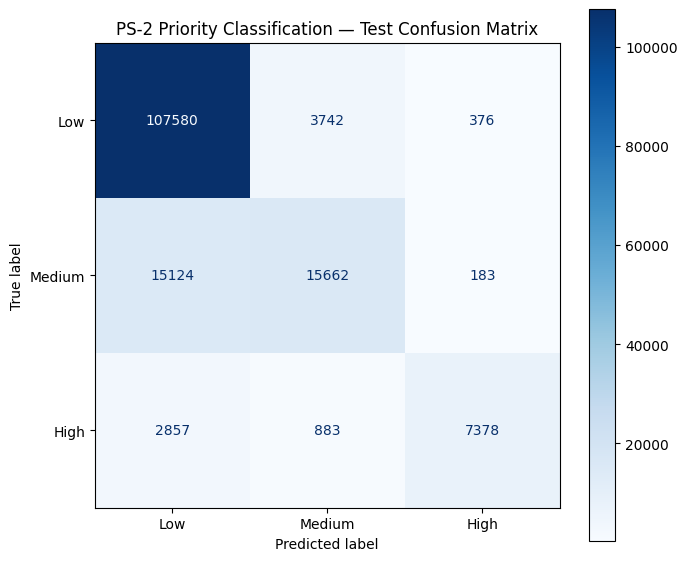


========== PS-2 FILES SAVED ==========
ps2_priority_svm_model.pkl
ps2_priority_tfidf_vectorizer.pkl


In [28]:
# ============================================================
# CELL 27 — FINAL PS-2 MODEL + TEST + SAVE
# ============================================================

import joblib
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Train final model with best C
# ------------------------------------------------------------

final_svm_p2 = LinearSVC(
    C=0.1,
    class_weight="balanced",
    max_iter=3000
)

final_svm_p2.fit(
    X_train_p2_tfidf,
    y_train_p2
)

# ------------------------------------------------------------
# Test prediction
# ------------------------------------------------------------

y_test_pred_p2 = final_svm_p2.predict(
    X_test_p2_tfidf
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

p2_accuracy = accuracy_score(
    y_test_p2,
    y_test_pred_p2
)

p2_precision = precision_score(
    y_test_p2,
    y_test_pred_p2,
    average="macro",
    zero_division=0
)

p2_recall = recall_score(
    y_test_p2,
    y_test_pred_p2,
    average="macro",
    zero_division=0
)

p2_f1 = f1_score(
    y_test_p2,
    y_test_pred_p2,
    average="macro",
    zero_division=0
)

p2_high_recall = recall_score(
    y_test_p2,
    y_test_pred_p2,
    labels=["High"],
    average=None,
    zero_division=0
)[0]

print("========== FINAL PS-2 TEST PERFORMANCE ==========")
print(f"Accuracy              : {p2_accuracy:.4f}")
print(f"Macro Precision       : {p2_precision:.4f}")
print(f"Macro Recall          : {p2_recall:.4f}")
print(f"Macro F1              : {p2_f1:.4f}")
print(f"High Priority Recall  : {p2_high_recall:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test_p2,
        y_test_pred_p2,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test_p2,
    y_test_pred_p2,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

plt.title("PS-2 Priority Classification — Test Confusion Matrix")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save model + vectorizer
# ------------------------------------------------------------

joblib.dump(
    final_svm_p2,
    "ps2_priority_svm_model.pkl"
)

joblib.dump(
    tfidf_p2,
    "ps2_priority_tfidf_vectorizer.pkl"
)

print("\n========== PS-2 FILES SAVED ==========")
print("ps2_priority_svm_model.pkl")
print("ps2_priority_tfidf_vectorizer.pkl")

ps3

In [133]:
# ============================================================
# PS-3 CELL 1 — QUERY/RESPONSE PAIR RECONSTRUCTION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("PS-3 — QUERY / RESPONSE PAIRS")
print("=" * 60)

thread_df = df[
    [
        "tweet_id",
        "author_id",
        "inbound",
        "text",
        "in_response_to_tweet_id"
    ]
].copy()

# Normalize IDs
thread_df["tweet_id_str"] = (
    pd.to_numeric(
        thread_df["tweet_id"],
        errors="coerce"
    )
    .astype("Int64")
    .astype(str)
    .replace("<NA>", np.nan)
)

thread_df["in_response_str"] = (
    pd.to_numeric(
        thread_df["in_response_to_tweet_id"],
        errors="coerce"
    )
    .astype("Int64")
    .astype(str)
    .replace("<NA>", np.nan)
)

# Clean raw text
thread_df["text"] = (
    thread_df["text"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Customer messages
customer_df = thread_df[
    thread_df["inbound"] == True
].copy()

# Company responses
company_df = thread_df[
    thread_df["inbound"] == False
].copy()

# Company response lookup
company_lookup = (
    company_df[
        [
            "tweet_id_str",
            "text",
            "author_id"
        ]
    ]
    .dropna(subset=["tweet_id_str"])
    .drop_duplicates("tweet_id_str")
    .set_index("tweet_id_str")
)

# Match customer message to company response
pairs = customer_df[
    [
        "in_response_str",
        "text"
    ]
].copy()

pairs["company_response"] = pairs[
    "in_response_str"
].map(
    company_lookup["text"]
)

pairs["support_company"] = pairs[
    "in_response_str"
].map(
    company_lookup["author_id"]
)

# Keep valid pairs
pairs = pairs[
    pairs["in_response_str"].notna()
    & pairs["company_response"].notna()
    & (pairs["text"].str.len() > 0)
    & (pairs["company_response"].str.len() > 0)
].copy()

pairs = pairs.rename(
    columns={"text": "customer_query"}
)

pairs = pairs[
    [
        "customer_query",
        "company_response",
        "support_company"
    ]
].drop_duplicates()

print("Total query-response pairs:", len(pairs))
print(
    "Unique companies:",
    pairs["support_company"].nunique()
)

display(pairs.head(10))

PS-3 — QUERY / RESPONSE PAIRS
Total query-response pairs: 559616
Unique companies: 108


,customer_query,company_response,support_company
1,@sprintcare and how do you propose we do that,@115712 I understand. I would like to assist y...,sprintcare
2,@sprintcare I have sent several private messag...,@115712 Please send us a Private Message so th...,sprintcare
4,@sprintcare I did.,@115712 Can you please send us a private messa...,sprintcare
8,@sprintcare You gonna magically change your co...,@115713 We understand your concerns and we'd l...,sprintcare
10,@sprintcare Since I signed up with you....Sinc...,@115713 H there! We'd definitely like to work ...,sprintcare
16,@Ask_Spectrum Would you like me to email you a...,@115716 What information is incorrect? ^JK,Ask_Spectrum
18,@Ask_Spectrum I received this from your corpor...,@115716 Our department is part of the corporat...,Ask_Spectrum
20,@Ask_Spectrum The correct way to do it is via ...,@115716 What information is incorrect? ^JK,Ask_Spectrum
21,@Ask_Spectrum That is INCORRECT information I ...,@115716 The information pertaining to the acco...,Ask_Spectrum
29,@VerizonSupport I finally got someone that hel...,@115719 Help has arrived! We are sorry to see ...,VerizonSupport


In [134]:
# ============================================================
# PS-3 CELL 2 — CLEANING + TRAIN / VALIDATION / TEST
# ============================================================

import re
from sklearn.model_selection import train_test_split


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"@\w+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-z0-9!?.,' ]+",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


pairs["customer_query_clean"] = (
    pairs["customer_query"]
    .apply(clean_text)
)

pairs["company_response_clean"] = (
    pairs["company_response"]
    .apply(clean_text)
)

# Remove very short records
pairs = pairs[
    (pairs["customer_query_clean"].str.len() >= 5)
    &
    (pairs["company_response_clean"].str.len() >= 5)
].copy()

# Remove duplicate query-response combinations
pairs = pairs.drop_duplicates(
    subset=[
        "customer_query_clean",
        "company_response_clean"
    ]
).reset_index(drop=True)

# Decoder sequence
pairs["decoder_response"] = (
    "<start> "
    + pairs["company_response_clean"]
    + " <end>"
)

# 80 / 10 / 10 split
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.20,
    random_state=42
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42
)

train_pairs = train_pairs.reset_index(drop=True)
val_pairs = val_pairs.reset_index(drop=True)
test_pairs = test_pairs.reset_index(drop=True)

print("=" * 60)
print("PS-3 — DATA SPLIT")
print("=" * 60)

print("Total      :", len(pairs))
print("Training   :", len(train_pairs))
print("Validation :", len(val_pairs))
print("Test       :", len(test_pairs))

display(
    train_pairs[
        [
            "customer_query_clean",
            "company_response_clean",
            "support_company"
        ]
    ].head(5)
)

PS-3 — DATA SPLIT
Total      : 535664
Training   : 428531
Validation : 53566
Test       : 53567


,customer_query_clean,company_response_clean,support_company
0,depends what they looked like,mm amp hp are signing in to answer your tweets...,VirginTrains
1,"sorry to have missed the call, i have my phone...",i called and left a message for you. please dm...,BofA_Help
2,iphone7,thanks for sharing that information. what ipho...,NikeSupport
3,"it's fine, i think it's actually just my area...","hello jordan, i do apologize for the issues yo...",Ask_Spectrum
4,"acabei de me apaixonar por essa companhia, e f...",here's to an unboolievably happyhalloween!,AmericanAir


In [135]:
# ============================================================
# PS-3 CELL 3 — TOKENIZATION + PADDING
# ============================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_QUERY_LEN = 50
MAX_RESPONSE_LEN = 60

QUERY_VOCAB_SIZE = 15000
RESPONSE_VOCAB_SIZE = 15000

TRAIN_N = min(
    50000,
    len(train_pairs)
)

VAL_N = min(
    5000,
    len(val_pairs)
)

TEST_N = min(
    5000,
    len(test_pairs)
)

# ------------------------------------------------------------
# Training text
# ------------------------------------------------------------

train_q = train_pairs[
    "customer_query_clean"
].astype(str).tolist()[:TRAIN_N]

val_q = val_pairs[
    "customer_query_clean"
].astype(str).tolist()[:VAL_N]

test_q = test_pairs[
    "customer_query_clean"
].astype(str).tolist()[:TEST_N]


train_r = train_pairs[
    "company_response_clean"
].astype(str).tolist()[:TRAIN_N]

val_r = val_pairs[
    "company_response_clean"
].astype(str).tolist()[:VAL_N]

test_r = test_pairs[
    "company_response_clean"
].astype(str).tolist()[:TEST_N]


# ------------------------------------------------------------
# Add decoder tokens
# ------------------------------------------------------------

train_r_start = [
    "<start> " + x + " <end>"
    for x in train_r
]

val_r_start = [
    "<start> " + x + " <end>"
    for x in val_r
]

test_r_start = [
    "<start> " + x + " <end>"
    for x in test_r
]


# ------------------------------------------------------------
# Query tokenizer
# ------------------------------------------------------------

query_tokenizer = Tokenizer(
    num_words=QUERY_VOCAB_SIZE,
    oov_token="<unk>",
    filters=""
)

query_tokenizer.fit_on_texts(train_q)


# ------------------------------------------------------------
# Response tokenizer
# ------------------------------------------------------------

response_tokenizer = Tokenizer(
    num_words=RESPONSE_VOCAB_SIZE,
    oov_token="<unk>",
    filters=""
)

response_tokenizer.fit_on_texts(
    train_r_start
)


# ------------------------------------------------------------
# Convert to padded sequences
# ------------------------------------------------------------

X_train = pad_sequences(
    query_tokenizer.texts_to_sequences(train_q),
    maxlen=MAX_QUERY_LEN,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    query_tokenizer.texts_to_sequences(val_q),
    maxlen=MAX_QUERY_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    query_tokenizer.texts_to_sequences(test_q),
    maxlen=MAX_QUERY_LEN,
    padding="post",
    truncating="post"
)


y_train = pad_sequences(
    response_tokenizer.texts_to_sequences(train_r_start),
    maxlen=MAX_RESPONSE_LEN,
    padding="post",
    truncating="post"
)

y_val = pad_sequences(
    response_tokenizer.texts_to_sequences(val_r_start),
    maxlen=MAX_RESPONSE_LEN,
    padding="post",
    truncating="post"
)

y_test = pad_sequences(
    response_tokenizer.texts_to_sequences(test_r_start),
    maxlen=MAX_RESPONSE_LEN,
    padding="post",
    truncating="post"
)


# Actual vocabulary sizes
query_vocab_size = min(
    QUERY_VOCAB_SIZE,
    len(query_tokenizer.word_index) + 1
)

response_vocab_size = min(
    RESPONSE_VOCAB_SIZE,
    len(response_tokenizer.word_index) + 1
)


print("=" * 60)
print("PS-3 — TOKENIZATION")
print("=" * 60)

print("Query vocabulary   :", query_vocab_size)
print("Response vocabulary:", response_vocab_size)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

PS-3 — TOKENIZATION
Query vocabulary   : 15000
Response vocabulary: 15000
X_train: (50000, 50)
y_train: (50000, 60)


In [136]:
# ============================================================
# PS-3 CELL 4 — SEQ2SEQ LSTM + ATTENTION
# ============================================================

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Attention,
    Concatenate
)

from tensorflow.keras.models import Model


EMBED_DIM = 64
LATENT_DIM = 128


# ------------------------------------------------------------
# Teacher forcing
# ------------------------------------------------------------

decoder_input_train = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_val = y_val[:, :-1]
decoder_target_val = y_val[:, 1:]


# ============================================================
# ENCODER
# ============================================================

encoder_inputs = Input(
    shape=(MAX_QUERY_LEN,),
    name="encoder_input"
)

encoder_embedding = Embedding(
    input_dim=query_vocab_size,
    output_dim=EMBED_DIM,
    mask_zero=True,
    name="encoder_embedding"
)

encoder_embedded = encoder_embedding(
    encoder_inputs
)

encoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedded
)


# ============================================================
# DECODER
# ============================================================

decoder_inputs = Input(
    shape=(MAX_RESPONSE_LEN - 1,),
    name="decoder_input"
)

decoder_embedding = Embedding(
    input_dim=response_vocab_size,
    output_dim=EMBED_DIM,
    mask_zero=True,
    name="decoder_embedding"
)

decoder_embedded = decoder_embedding(
    decoder_inputs
)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded,
    initial_state=[
        state_h,
        state_c
    ]
)


# ============================================================
# ATTENTION
# ============================================================

attention = Attention(
    name="attention"
)

attention_context = attention(
    [
        decoder_outputs,
        encoder_outputs
    ]
)


# ============================================================
# COMBINE
# ============================================================

decoder_combined = Concatenate(
    axis=-1,
    name="decoder_attention"
)(
    [
        decoder_outputs,
        attention_context
    ]
)


# ============================================================
# OUTPUT
# ============================================================

response_output_layer = Dense(
    response_vocab_size,
    activation="softmax",
    name="response_output"
)

outputs = response_output_layer(
    decoder_combined
)


improved_model = Model(
    [
        encoder_inputs,
        decoder_inputs
    ],
    outputs,
    name="PS3_Seq2Seq_Attention"
)


# ============================================================
# MASKED LOSS
# ============================================================

def masked_loss(y_true, y_pred):

    y_true = tf.cast(
        y_true,
        tf.int32
    )

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true,
        y_pred
    )

    mask = tf.cast(
        tf.not_equal(y_true, 0),
        loss.dtype
    )

    return (
        tf.reduce_sum(loss * mask)
        /
        tf.maximum(
            tf.reduce_sum(mask),
            1.0
        )
    )


def masked_accuracy(y_true, y_pred):

    y_true = tf.cast(
        y_true,
        tf.int32
    )

    prediction = tf.argmax(
        y_pred,
        axis=-1,
        output_type=tf.int32
    )

    mask = tf.cast(
        tf.not_equal(y_true, 0),
        tf.float32
    )

    correct = tf.cast(
        tf.equal(
            y_true,
            prediction
        ),
        tf.float32
    )

    return (
        tf.reduce_sum(correct * mask)
        /
        tf.maximum(
            tf.reduce_sum(mask),
            1.0
        )
    )


improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=masked_loss,
    metrics=[masked_accuracy]
)


print("=" * 60)
print("PS-3 — MODEL CREATED")
print("=" * 60)

improved_model.summary()

PS-3 — MODEL CREATED
Model: "PS3_Seq2Seq_Attention"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 50)]                 0         []                            
                                                                                                  
 decoder_input (InputLayer)  [(None, 59)]                 0         []                            
                                                                                                  
 encoder_embedding (Embeddi  (None, 50, 64)               960000    ['encoder_input[0][0]']       
 ng)                                                                                              
                                                                                                  
 decoder_embedding (Embeddi  (None, 59, 64)              

In [137]:
# ============================================================
# PS-3 CELL 5 — TRAINING
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


print("=" * 60)
print("PS-3 — TRAINING")
print("=" * 60)


history = improved_model.fit(

    [
        X_train,
        decoder_input_train
    ],

    decoder_target_train,

    validation_data=(

        [
            X_val,
            decoder_input_val
        ],

        decoder_target_val
    ),

    batch_size=256,

    epochs=8,

    callbacks=[

        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-5
        )

    ],

    verbose=1
)


print("\nPS-3 training completed.")

PS-3 — TRAINING
Epoch 1/8


W0000 00:00:1787923520.195688       1 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


196/196 [==============================] - ETA: 0s - loss: 6.7734 - masked_accuracy: 0.0607

W0000 00:00:1787923857.355924       1 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


196/196 [==============================] - 360s 2s/step - loss: 6.7734 - masked_accuracy: 0.0607 - val_loss: 6.1617 - val_masked_accuracy: 0.0688 - lr: 0.0010
Epoch 2/8
196/196 [==============================] - 415s 2s/step - loss: 6.0633 - masked_accuracy: 0.0835 - val_loss: 5.8388 - val_masked_accuracy: 0.0994 - lr: 0.0010
Epoch 3/8
196/196 [==============================] - 413s 2s/step - loss: 5.6558 - masked_accuracy: 0.1292 - val_loss: 5.3590 - val_masked_accuracy: 0.1578 - lr: 0.0010
Epoch 4/8
196/196 [==============================] - 450s 2s/step - loss: 5.2040 - masked_accuracy: 0.1793 - val_loss: 4.9855 - val_masked_accuracy: 0.2015 - lr: 0.0010
Epoch 5/8
196/196 [==============================] - 435s 2s/step - loss: 4.8712 - masked_accuracy: 0.2143 - val_loss: 4.7241 - val_masked_accuracy: 0.2265 - lr: 0.0010
Epoch 6/8
196/196 [==============================] - 436s 2s/step - loss: 4.6297 - masked_accuracy: 0.2368 - val_loss: 4.5445 - val_masked_accuracy: 0.2437 - lr: 0.0

In [138]:
# ============================================================
# PS-3 CELL 6 — INFERENCE MODELS
# ============================================================

import tensorflow as tf


# ============================================================
# ENCODER INFERENCE
# ============================================================

encoder_model = tf.keras.Model(
    inputs=encoder_inputs,
    outputs=[
        encoder_outputs,
        state_h,
        state_c
    ],
    name="PS3_Encoder_Inference"
)


# ============================================================
# DECODER INPUTS
# ============================================================

decoder_token_input = tf.keras.Input(
    shape=(1,),
    dtype="int32",
    name="decoder_token_input"
)

decoder_state_h_input = tf.keras.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_h"
)

decoder_state_c_input = tf.keras.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_c"
)

encoder_context_input = tf.keras.Input(
    shape=(MAX_QUERY_LEN, LATENT_DIM),
    name="encoder_context"
)


# ============================================================
# DECODER EMBEDDING
# ============================================================

decoder_emb = decoder_embedding(
    decoder_token_input
)


# ============================================================
# DECODER LSTM
# ============================================================

decoder_out, decoder_h, decoder_c = decoder_lstm(
    decoder_emb,
    initial_state=[
        decoder_state_h_input,
        decoder_state_c_input
    ]
)


# ============================================================
# ATTENTION
# ============================================================

attention_context_step = attention(
    [
        decoder_out,
        encoder_context_input
    ]
)


# ============================================================
# COMBINE
# ============================================================

decoder_combined_step = Concatenate(
    axis=-1,
    name="decoder_attention_step"
)(
    [
        decoder_out,
        attention_context_step
    ]
)


# ============================================================
# DENSE OUTPUT
# ============================================================

decoder_output = response_output_layer(
    decoder_combined_step
)


# ============================================================
# DECODER MODEL
# ============================================================

decoder_model = tf.keras.Model(

    inputs=[
        decoder_token_input,
        decoder_state_h_input,
        decoder_state_c_input,
        encoder_context_input
    ],

    outputs=[
        decoder_output,
        decoder_h,
        decoder_c
    ],

    name="PS3_Decoder_Inference"
)


print("PS-3 inference models created successfully.")

print(
    "Encoder:",
    encoder_model.input_shape,
    "→",
    encoder_model.output_shape
)

print(
    "Decoder:",
    decoder_model.input_shape,
    "→",
    decoder_model.output_shape
)

PS-3 inference models created successfully.
Encoder: (None, 50) → [(None, 50, 128), (None, 128), (None, 128)]
Decoder: [(None, 1), (None, 128), (None, 128), (None, 50, 128)] → [(None, 1, 15000), (None, 128), (None, 128)]


In [82]:
!pip install rouge-score

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [141]:
# ============================================================
# PS-3 CELL 7 — RESPONSE GENERATION
# ============================================================

import numpy as np
import tensorflow as tf


response_index_word = {
    index: word
    for word, index
    in response_tokenizer.word_index.items()
}


start_token = response_tokenizer.word_index.get(
    "<start>"
)

end_token = response_tokenizer.word_index.get(
    "<end>"
)

unk_token = response_tokenizer.word_index.get(
    "<unk>"
)


def generate_response(
    text,
    max_length=50
):

    cleaned_text = clean_text(text)

    sequence = query_tokenizer.texts_to_sequences(
        [cleaned_text]
    )

    sequence = tf.keras.preprocessing.sequence.pad_sequences(
        sequence,
        maxlen=MAX_QUERY_LEN,
        padding="post",
        truncating="post"
    )

    # Encode
    encoder_context, h, c = (
        encoder_model.predict(
            sequence,
            verbose=0
        )
    )

    target_token = np.array(
        [[start_token]],
        dtype=np.int32
    )

    generated_words = []
    generated_tokens = []

    for _ in range(max_length):

        output_tokens, h, c = (
            decoder_model.predict(
                [
                    target_token,
                    h,
                    c,
                    encoder_context
                ],
                verbose=0
            )
        )

        probabilities = (
            output_tokens[0, -1, :].copy()
        )

        # Never generate special tokens
        if unk_token is not None:
            probabilities[unk_token] = 0.0

        if start_token is not None:
            probabilities[start_token] = 0.0

        # Reduce repetition
        if generated_tokens:
            for token in set(generated_tokens[-3:]):
                probabilities[token] *= 0.20

        sampled_token = int(
            np.argmax(probabilities)
        )

        if (
            end_token is not None
            and sampled_token == end_token
        ):
            break

        word = response_index_word.get(
            sampled_token,
            ""
        )

        if not word:
            break

        if word in [
            "<start>",
            "<end>",
            "<unk>"
        ]:
            break

        generated_words.append(word)
        generated_tokens.append(sampled_token)

        target_token = np.array(
            [[sampled_token]],
            dtype=np.int32
        )

    return " ".join(
        generated_words
    ).strip()

In [142]:
# ============================================================
# PS-3 CELL 8 — RESPONSE QUALITY CHECK
# ============================================================

import re


def is_poor_response(
    query,
    response
):

    if not response:
        return True

    response = str(response).strip().lower()

    words = response.split()

    # Too short
    if len(words) < 5:
        return True

    # Too long
    if len(words) > 50:
        return True

    # Special tokens
    if "<unk>" in response:
        return True

    if "<start>" in response:
        return True

    if "<end>" in response:
        return True

    # --------------------------------------------------------
    # Repetition
    # --------------------------------------------------------

    counts = {}

    for word in words:

        word = re.sub(
            r"[^a-z]",
            "",
            word
        )

        if word:
            counts[word] = (
                counts.get(word, 0) + 1
            )

    if counts:

        if max(counts.values()) >= 5:
            return True

    # Consecutive repetition
    for i in range(1, len(words)):

        if words[i] == words[i - 1]:

            return True

    # --------------------------------------------------------
    # Character sanity
    # --------------------------------------------------------

    letters = sum(
        char.isalpha()
        for char in response
    )

    if len(response) > 0:

        if letters / len(response) < 0.70:
            return True

    # --------------------------------------------------------
    # Query relevance
    # --------------------------------------------------------

    query_words = set(
        re.findall(
            r"[a-z]+",
            query.lower()
        )
    )

    response_words = set(
        re.findall(
            r"[a-z]+",
            response
        )
    )

    stop_words = {
        "the", "a", "an",
        "is", "are", "am",
        "to", "of", "for",
        "and", "or", "i",
        "my", "me", "we",
        "you", "your", "it",
        "this", "that",
        "with", "on", "in"
    }

    useful_query = (
        query_words - stop_words
    )

    useful_response = (
        response_words - stop_words
    )

    overlap = (
        useful_query &
        useful_response
    )

    # If there is no useful relationship at all,
    # reject the generated answer.
    if (
        len(useful_query) >= 3
        and len(overlap) == 0
    ):
        return True

    return False

In [150]:
# ============================================================
# PS-3 CELL 9 — TF-IDF RETRIEVAL FALLBACK
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import numpy as np


# ------------------------------------------------------------
# Retrieval data
# ------------------------------------------------------------

retrieval_queries = train_q
retrieval_responses = train_r


# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

retrieval_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_features=50000,
    sublinear_tf=True
)

retrieval_matrix = (
    retrieval_vectorizer.fit_transform(
        retrieval_queries
    )
)


# ------------------------------------------------------------
# Clean retrieved response
# ------------------------------------------------------------

def clean_retrieved_response(response):

    if not response:
        return ""

    response = str(response).strip()

    # Remove URLs
    response = re.sub(
        r"https?://\S+|www\.\S+",
        "",
        response
    )

    # Remove mentions
    response = re.sub(
        r"@\w+",
        "",
        response
    )

    # Remove obvious trailing noise
    response = re.sub(
        r"\s+\b[a-z]{1,2}\s*$",
        "",
        response,
        flags=re.IGNORECASE
    )

    # Remove repeated spaces
    response = re.sub(
        r"\s+",
        " ",
        response
    ).strip()

    return response


# ------------------------------------------------------------
# Retrieval function
# ------------------------------------------------------------

def retrieve_response(
    query,
    min_similarity=0.05
):

    cleaned_query = clean_text(
        query
    )

    query_vector = (
        retrieval_vectorizer.transform(
            [cleaned_query]
        )
    )

    similarities = cosine_similarity(
        query_vector,
        retrieval_matrix
    )[0]

    best_index = int(
        np.argmax(similarities)
    )

    best_score = float(
        similarities[best_index]
    )

    if best_score < min_similarity:

        return "", best_score

    response = clean_retrieved_response(
        retrieval_responses[best_index]
    )

    return response, best_score

In [151]:
# ============================================================
# PS-3 CELL 10 — FINAL RESPONSE PIPELINE
# ============================================================

def get_final_response(query):

    # --------------------------------------------------------
    # 1. Try Seq2Seq + Attention
    # --------------------------------------------------------

    generated = generate_response(
        query
    )

    if not is_poor_response(
        query,
        generated
    ):

        return {
            "response": generated,
            "method": "Seq2Seq + Attention",
            "similarity": None
        }


    # --------------------------------------------------------
    # 2. Use TF-IDF retrieval
    # --------------------------------------------------------

    retrieved, similarity = (
        retrieve_response(query)
    )

    if retrieved:

        return {
            "response": retrieved,
            "method": "TF-IDF Retrieval",
            "similarity": similarity
        }


    # --------------------------------------------------------
    # 3. Safe fallback
    # --------------------------------------------------------

    return {
        "response": (
            "We're sorry for the inconvenience. "
            "Please provide more details about your "
            "issue so our support team can assist you."
        ),
        "method": "Safe Fallback",
        "similarity": None
    }


# ------------------------------------------------------------
# Quick test
# ------------------------------------------------------------

test_inputs = [
    "I cannot log into my account",
    "I was charged twice for the same order",
    "The application is not working properly",
    "My package has not arrived yet",
    "I want to complain about the service"
]


print("=" * 70)
print("PS-3 RESPONSE TEST")
print("=" * 70)


for query in test_inputs:

    result = get_final_response(
        query
    )

    print("\nCustomer:")
    print(query)

    print("\nResponse:")
    print(result["response"])

    print("\nMethod:")
    print(result["method"])

    if result["similarity"] is not None:

        print(
            "Similarity:",
            round(
                result["similarity"],
                4
            )
        )

    print("-" * 70)

PS-3 RESPONSE TEST

Customer:
I cannot log into my account

Response:
hi there, sorry to hear about the inconvenience. please dm us your email address and we'll be happy to look into this for you.

Method:
Seq2Seq + Attention
----------------------------------------------------------------------

Customer:
I was charged twice for the same order

Response:
hi there, sorry to hear about the trouble with your order to our attention. please dm us your email address so we can look into this for you.

Method:
Seq2Seq + Attention
----------------------------------------------------------------------

Customer:
The application is not working properly

Response:
hello, please state the exact issue along with the affected mobile number via dm for checks and assistance. thank you. ro.

Method:
TF-IDF Retrieval
Similarity: 0.5238
----------------------------------------------------------------------

Customer:
My package has not arrived yet

Response:
please let us know if doesn't arrive by friday

In [152]:
# ============================================================
# PS-3 CELL 11 — BLEU + ROUGE EVALUATION
# ============================================================

from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

from rouge_score import rouge_scorer

import numpy as np


N_EVAL = min(
    50,
    len(test_q)
)

smooth = SmoothingFunction().method1

rouge = rouge_scorer.RougeScorer(
    [
        "rouge1",
        "rougeL"
    ],
    use_stemmer=True
)


bleu_scores = []
rouge1_scores = []
rougeL_scores = []


print("=" * 70)
print("PS-3 — BLEU / ROUGE")
print("=" * 70)


for i in range(N_EVAL):

    query = test_q[i]

    actual_response = test_r[i]

    result = get_final_response(
        query
    )

    generated_response = (
        result["response"]
    )

    reference = actual_response.split()
    candidate = generated_response.split()

    if reference and candidate:

        bleu = sentence_bleu(
            [reference],
            candidate,
            smoothing_function=smooth
        )

    else:

        bleu = 0.0

    rouge_result = rouge.score(
        actual_response,
        generated_response
    )

    rouge1 = rouge_result[
        "rouge1"
    ].fmeasure

    rougeL = rouge_result[
        "rougeL"
    ].fmeasure

    bleu_scores.append(bleu)
    rouge1_scores.append(rouge1)
    rougeL_scores.append(rougeL)

    if i < 5:

        print("\n" + "-" * 70)

        print("Query:", query)

        print(
            "Actual:",
            actual_response
        )

        print(
            "Generated:",
            generated_response
        )

        print(
            "Method:",
            result["method"]
        )

        print(
            "BLEU:",
            round(bleu, 4)
        )

        print(
            "ROUGE-1:",
            round(rouge1, 4)
        )

        print(
            "ROUGE-L:",
            round(rougeL, 4)
        )


print("\n" + "=" * 70)

print(
    "Average BLEU:",
    round(
        np.mean(bleu_scores),
        4
    )
)

print(
    "Average ROUGE-1:",
    round(
        np.mean(rouge1_scores),
        4
    )
)

print(
    "Average ROUGE-L:",
    round(
        np.mean(rougeL_scores),
        4
    )
)

PS-3 — BLEU / ROUGE

----------------------------------------------------------------------
Query: it was delivered by amazon drivers, and yes, delivered but left in an unsafe location despite instructions left on the order! front door and enclosed patio are not the same thing.
Actual: this isn't what we like hearing! who was the carrier for your order? was the package delivered? dd
Generated: i am sorry to hear there was no unattended delivery preference set. was this order dispatched by amazon?
Method: TF-IDF Retrieval
BLEU: 0.0142
ROUGE-1: 0.2703
ROUGE-L: 0.1622

----------------------------------------------------------------------
Query: as you can see, i could never make it all the way down to leave party.
Actual: hi there! would you be able to send us a picture or video of what you are seeing with party chat? 1 2 ja
Generated: hi there! can you tell us a dm with your email address and we'll be happy to help.
Method: Seq2Seq + Attention
BLEU: 0.0275
ROUGE-1: 0.3721
ROUGE-L: 0.279

In [153]:
# ============================================================
# PS-3 CELL 12 — SAVE FINAL ARTIFACTS
# ============================================================

import joblib


# ============================================================
# SAVE INFERENCE MODELS
# ============================================================

encoder_model.save(
    "ps3_encoder.keras"
)

decoder_model.save(
    "ps3_decoder.keras"
)


# ============================================================
# SAVE TOKENIZERS
# ============================================================

joblib.dump(
    query_tokenizer,
    "ps3_query_tokenizer.pkl"
)

joblib.dump(
    response_tokenizer,
    "ps3_response_tokenizer.pkl"
)


# ============================================================
# SAVE RETRIEVAL BUNDLE
# ============================================================

ps3_retrieval_bundle = {

    "vectorizer":
        retrieval_vectorizer,

    "matrix":
        retrieval_matrix,

    "responses":
        retrieval_responses
}


joblib.dump(
    ps3_retrieval_bundle,
    "ps3_retrieval_bundle.pkl"
)


# ============================================================
# SAVE COMPLETE TRAINED MODEL
# ============================================================

improved_model.save(
    "ps3_seq2seq_attention.keras"
)


print("=" * 70)
print("PS-3 ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 70)

print("ps3_encoder.keras")
print("ps3_decoder.keras")
print("ps3_seq2seq_attention.keras")
print("ps3_query_tokenizer.pkl")
print("ps3_response_tokenizer.pkl")
print("ps3_retrieval_bundle.pkl")

PS-3 ARTIFACTS SAVED SUCCESSFULLY
ps3_encoder.keras
ps3_decoder.keras
ps3_seq2seq_attention.keras
ps3_query_tokenizer.pkl
ps3_response_tokenizer.pkl
ps3_retrieval_bundle.pkl


In [116]:
# ============================================================
# PS-4 — RESPONSE TIME DATASET (FIXED)
# ============================================================

import pandas as pd
import numpy as np

ps4_df = df.copy()

ps4_df["created_at"] = pd.to_datetime(
    ps4_df["created_at"],
    errors="coerce",
    utc=True
)

# Normalize IDs for reliable parent lookup
ps4_df["tweet_id_num"] = pd.to_numeric(
    ps4_df["tweet_id"], errors="coerce"
)
ps4_df["parent_id_num"] = pd.to_numeric(
    ps4_df["in_response_to_tweet_id"], errors="coerce"
)

# Lookup customer tweets by tweet ID
customer_lookup = (
    ps4_df[ps4_df["inbound"] == True][
        ["tweet_id_num", "created_at", "text"]
    ]
    .dropna(subset=["tweet_id_num"])
    .drop_duplicates("tweet_id_num")
    .set_index("tweet_id_num")
)

# Only company replies are valid response events.
# The parent must be an inbound customer message.
company_replies = ps4_df[
    (ps4_df["inbound"] == False) &
    ps4_df["parent_id_num"].notna()
].copy()

company_replies["customer_time"] = company_replies[
    "parent_id_num"
].map(customer_lookup["created_at"])

company_replies["customer_text"] = company_replies[
    "parent_id_num"
].map(customer_lookup["text"])

# Response time = company reply time - customer query time
company_replies["response_time"] = (
    company_replies["created_at"] -
    company_replies["customer_time"]
).dt.total_seconds() / 60

ps4_data = company_replies[
    company_replies["customer_time"].notna() &
    company_replies["customer_text"].notna() &
    (company_replies["response_time"] >= 0)
][[
    "customer_time",
    "response_time",
    "customer_text",
    "author_id"
]].rename(
    columns={
        "customer_text": "text",
        "author_id": "company"
    }
).copy()

ps4_data = ps4_data[
    ps4_data["text"].fillna("").str.strip().ne("")
].reset_index(drop=True)

print("========== PS-4 FIXED DATASET ==========")
print("Valid customer -> company response pairs:", len(ps4_data))
print("Unique support companies:", ps4_data["company"].nunique())
print(ps4_data.head())


========== PS-4 FIXED DATASET ==========
Valid customer -> company response pairs: 1261888
Unique support companies: 108
              customer_time  response_time  \
0 2017-10-31 22:08:27+00:00       2.333333   
1 2017-10-31 21:49:35+00:00       5.233333   
2 2017-10-31 21:45:10+00:00       1.233333   
3 2017-10-31 22:04:47+00:00       5.800000   
4 2017-10-31 20:00:43+00:00       2.800000   

                                                text     company  
0  @sprintcare I have sent several private messag...  sprintcare  
1                                 @sprintcare I did.  sprintcare  
2          @sprintcare is the worst customer service  sprintcare  
3  @sprintcare You gonna magically change your co...  sprintcare  
4  @sprintcare Since I signed up with you....Sinc...  sprintcare  


In [117]:
# ============================================================
# PS-4 — FEATURE ENGINEERING
# ============================================================

import numpy as np
import pandas as pd

ps4_data["customer_time"] = pd.to_datetime(
    ps4_data["customer_time"]
)

# ============================================================
# BASIC TEXT FEATURES
# ============================================================

ps4_data["message_length"] = (
    ps4_data["text"]
    .fillna("")
    .str.len()
)

ps4_data["word_count"] = (
    ps4_data["text"]
    .fillna("")
    .str.split()
    .str.len()
)

# ============================================================
# TIME FEATURES
# ============================================================

ps4_data["hour"] = (
    ps4_data["customer_time"]
    .dt.hour
)

ps4_data["day_of_week"] = (
    ps4_data["customer_time"]
    .dt.dayofweek
)

# ============================================================
# URGENCY FEATURE
# ============================================================

urgency_words = (
    r"\burgent\b|"
    r"\bimmediately\b|"
    r"\basap\b|"
    r"\bhelp\b|"
    r"\bemergency\b|"
    r"\bcritical\b|"
    r"\bnow\b"
)

ps4_data["urgency"] = (
    ps4_data["text"]
    .fillna("")
    .str.lower()
    .str.contains(
        urgency_words,
        regex=True
    )
    .astype(int)
)

# ============================================================
# PS-1 — PREDICT INTENT
# ============================================================

ps4_intent_features = tfidf.transform(
    ps4_data["text"].fillna("").tolist()
)

ps4_data["intent"] = final_svm.predict(
    ps4_intent_features
)

# ============================================================
# PS-2 — PREDICT PRIORITY
# ============================================================

ps4_priority_features = tfidf_p2.transform(
    ps4_data["text"].fillna("").tolist()
)

ps4_data["priority"] = final_svm_p2.predict(
    ps4_priority_features
)

# ============================================================
# CLEAN INVALID RESPONSE TIMES
# ============================================================

ps4_data = ps4_data[
    ps4_data["response_time"].notna() &
    (ps4_data["response_time"] >= 0)
].copy()

print("========== PS-4 FEATURES ==========")

print("Rows:", len(ps4_data))

print(
    ps4_data[
        [
            "message_length",
            "word_count",
            "hour",
            "day_of_week",
            "urgency",
            "intent",
            "priority",
            "company",
            "response_time"
        ]
    ].head()
)

print("\nIntent distribution:")
print(ps4_data["intent"].value_counts())

print("\nPriority distribution:")
print(ps4_data["priority"].value_counts())

print("\nUnique companies:")
print(ps4_data["company"].nunique())

========== PS-4 FEATURES ==========
Rows: 1261888
   message_length  word_count  hour  day_of_week  urgency           intent  \
0              82          14    22            1        0  General Inquiry   
1              18           3    21            1        0  General Inquiry   
2              41           6    21            1        0        Complaint   
3              89          16    22            1        0  General Inquiry   
4              53           9    20            1        0  General Inquiry   

  priority     company  response_time  
0      Low  sprintcare       2.333333  
1      Low  sprintcare       5.233333  
2      Low  sprintcare       1.233333  
3      Low  sprintcare       5.800000  
4      Low  sprintcare       2.800000  

Intent distribution:
intent
General Inquiry       835836
Technical Issue       212420
Billing Issue         140626
Complaint              44853
Account Management     28153
Name: count, dtype: int64

Priority distribution:
priority
Low     

In [118]:
# ============================================================
# PS-4 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

features = [
    "message_length",
    "word_count",
    "hour",
    "day_of_week",
    "urgency"
]

X = ps4_data[features]
y = ps4_data["response_time"]

# Use a representative sample for faster training
X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=200000,
    random_state=42
)

# Split into train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sample,
    y_sample,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("========== PS-4 DATA SPLIT ==========")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

========== PS-4 DATA SPLIT ==========
Training   : (160000, 5)
Validation : (20000, 5)
Test       : (20000, 5)


In [119]:
# ============================================================
# PS-4 — REGRESSION MODELS
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    results.append({
        "Model": name,
        "MAE (minutes)": mae,
        "RMSE (minutes)": rmse,
        "R²": r2
    })

results_df = pd.DataFrame(results)

print("\n========== PS-4 MODEL COMPARISON ==========")
print(results_df.round(4))


Training Linear Regression...

Training Random Forest...

Training XGBoost...

========== PS-4 MODEL COMPARISON ==========
               Model  MAE (minutes)  RMSE (minutes)      R²
0  Linear Regression       493.5197      11174.0310  0.0000
1      Random Forest       562.1095      11259.1734 -0.0153
2            XGBoost       483.5409      11175.2647 -0.0002


In [120]:
# ============================================================
# PS-4 — ADD CATEGORICAL FEATURES
# ============================================================

from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# ============================================================
# CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "intent",
    "priority",
    "company"
]

categorical_sample = (
    ps4_data.loc[
        X_sample.index,
        categorical_features
    ]
    .fillna("unknown")
    .astype(str)
)

# ============================================================
# ONE-HOT ENCODER
# ============================================================

encoder = OneHotEncoder(
    handle_unknown="ignore"
)

categorical_encoded = encoder.fit_transform(
    categorical_sample
)

# ============================================================
# NUMERIC FEATURES
# ============================================================

numeric_feature_names = [
    "message_length",
    "word_count",
    "hour",
    "day_of_week",
    "urgency"
]

numeric_features = X_sample[
    numeric_feature_names
].values

# ============================================================
# COMBINE NUMERIC + CATEGORICAL FEATURES
# ============================================================

X_combined = hstack([
    csr_matrix(numeric_features),
    categorical_encoded
]).tocsr()

# ============================================================
# SPLIT USING SAME INDICES
# ============================================================

train_idx = X_train.index
val_idx = X_val.index
test_idx = X_test.index

X_train_final = X_combined[
    X_sample.index.get_indexer(train_idx)
]

X_val_final = X_combined[
    X_sample.index.get_indexer(val_idx)
]

X_test_final = X_combined[
    X_sample.index.get_indexer(test_idx)
]

print("========== PS-4 ENHANCED FEATURES ==========")

print("Numeric features:")
print(numeric_feature_names)

print("\nCategorical features:")
print(categorical_features)

print("\nTraining:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

print(
    "\nTotal categorical encoded features:",
    categorical_encoded.shape[1]
)

========== PS-4 ENHANCED FEATURES ==========
Numeric features:
['message_length', 'word_count', 'hour', 'day_of_week', 'urgency']

Categorical features:
['intent', 'priority', 'company']

Training: (160000, 121)
Validation: (20000, 121)
Test: (20000, 121)

Total categorical encoded features: 116


In [121]:
# ============================================================
# PS-4 — ENHANCED MODEL COMPARISON
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

enhanced_results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_final, y_train)

    pred = model.predict(X_val_final)

    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)

    enhanced_results.append({
        "Model": name,
        "MAE (minutes)": mae,
        "RMSE (minutes)": rmse,
        "R²": r2
    })

enhanced_results_df = pd.DataFrame(enhanced_results)

print("\n========== PS-4 ENHANCED MODEL COMPARISON ==========")
print(enhanced_results_df.round(4))


Training Linear Regression...

Training Random Forest...

Training XGBoost...

========== PS-4 ENHANCED MODEL COMPARISON ==========
               Model  MAE (minutes)  RMSE (minutes)      R²
0  Linear Regression       400.5931      11162.4769  0.0021
1      Random Forest       382.0939      11192.3859 -0.0033
2            XGBoost       408.8275      11486.1855 -0.0566


In [122]:
# ============================================================
# PS-4 — RESPONSE TIME DISTRIBUTION
# ============================================================

print("========== RESPONSE TIME STATISTICS ==========")

print(y_sample.describe())

print("\n========== PERCENTILES ==========")

print(
    y_sample.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nMaximum response time:",
      y_sample.max())

print("\nResponses above 24 hours:",
      (y_sample > 1440).sum())

print("Responses above 7 days:",
      (y_sample > 10080).sum())

========== RESPONSE TIME STATISTICS ==========
count    2.000000e+05
mean     2.946986e+02
std      5.653095e+03
min      0.000000e+00
25%      6.183333e+00
50%      2.103333e+01
75%      1.069667e+02
max      1.815924e+06
Name: response_time, dtype: float64

========== PERCENTILES ==========
0.50      21.033333
0.75     106.966667
0.90     532.435000
0.95    1181.338333
0.99    4782.473667
Name: response_time, dtype: float64

Maximum response time: 1815924.0666666667

Responses above 24 hours: 8136
Responses above 7 days: 393


In [123]:
# ============================================================
# PS-4 — OUTLIER HANDLING
# ============================================================

upper_limit = y_sample.quantile(0.99)

mask = y_sample <= upper_limit

X_clean = X_sample.loc[mask].copy()
y_clean = y_sample.loc[mask].copy()

print("========== PS-4 CLEANED TARGET ==========")
print("Original samples :", len(y_sample))
print("After removing outliers :", len(y_clean))
print("Removed :", len(y_sample) - len(y_clean))
print("Upper limit :", round(upper_limit, 2), "minutes")
print("Maximum kept :", round(y_clean.max(), 2), "minutes")

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\n========== NEW PS-4 SPLIT ==========")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

========== PS-4 CLEANED TARGET ==========
Original samples : 200000
After removing outliers : 198000
Removed : 2000
Upper limit : 4782.47 minutes
Maximum kept : 4782.47 minutes

========== NEW PS-4 SPLIT ==========
Training   : (158400, 5)
Validation : (19800, 5)
Test       : (19800, 5)


In [124]:
# ============================================================
# PS-4 — FINAL REGRESSION MODELS
# LOG1P TARGET TRANSFORMATION
# ============================================================

import numpy as np
import pandas as pd

from scipy.sparse import hstack, csr_matrix

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. REBUILD CATEGORICAL FEATURES
# ============================================================

clean_indices = X_clean.index

categorical_clean = (
    ps4_data.loc[
        clean_indices,
        [
            "intent",
            "priority",
            "company"
        ]
    ]
    .fillna("unknown")
    .astype(str)
)


categorical_encoded_clean = encoder.transform(
    categorical_clean
)


# ============================================================
# 2. NUMERIC FEATURES
# ============================================================

numeric_feature_names = [
    "message_length",
    "word_count",
    "hour",
    "day_of_week",
    "urgency"
]


numeric_clean = X_clean[
    numeric_feature_names
].values


# ============================================================
# 3. COMBINE NUMERIC + CATEGORICAL FEATURES
# ============================================================

X_clean_final = hstack([
    csr_matrix(numeric_clean),
    categorical_encoded_clean
]).tocsr()


# ============================================================
# 4. ALIGN TRAIN / VALIDATION / TEST DATA
# ============================================================

train_pos = X_clean.index.get_indexer(
    X_train.index
)

val_pos = X_clean.index.get_indexer(
    X_val.index
)

test_pos = X_clean.index.get_indexer(
    X_test.index
)


if (
    (train_pos < 0).any()
    or (val_pos < 0).any()
    or (test_pos < 0).any()
):

    raise ValueError(
        "Some train/validation/test indices "
        "were not found in X_clean."
    )


X_train_final = X_clean_final[
    train_pos
]

X_val_final = X_clean_final[
    val_pos
]

X_test_final = X_clean_final[
    test_pos
]


print(
    "========== FINAL PS-4 MATRICES =========="
)

print(
    "Train      :",
    X_train_final.shape
)

print(
    "Validation :",
    X_val_final.shape
)

print(
    "Test       :",
    X_test_final.shape
)


# ============================================================
# 5. LOG1P TARGET TRANSFORMATION
# ============================================================

# Response time can contain very large values.
# log1p reduces the effect of extreme response times.

y_train_log = np.log1p(
    np.clip(
        y_train.values,
        0,
        None
    )
)


y_val_actual = y_val.values

y_test_actual = y_test.values


# ============================================================
# 6. FINAL MODELS
# ============================================================

final_models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}


final_results = []


# ============================================================
# 7. TRAIN + VALIDATE
# ============================================================

for name, model in final_models.items():

    print(
        f"\nTraining {name}..."
    )


    # Train on log-transformed response time
    model.fit(
        X_train_final,
        y_train_log
    )


    # Predict log(response_time + 1)
    pred_log = model.predict(
        X_val_final
    )


    # Convert back to original minutes
    pred = np.expm1(
        pred_log
    )


    # Safety limits
    pred = np.clip(
        pred,
        0,
        float(
            y_clean.max()
        )
    )


    final_results.append({

        "Model": name,

        "MAE (minutes)": mean_absolute_error(
            y_val_actual,
            pred
        ),

        "RMSE (minutes)": np.sqrt(
            mean_squared_error(
                y_val_actual,
                pred
            )
        ),

        "R²": r2_score(
            y_val_actual,
            pred
        )
    })


# ============================================================
# 8. MODEL COMPARISON
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)


print(
    "\n========== FINAL PS-4 MODEL COMPARISON =========="
)


print(
    final_results_df.round(4)
)


# ============================================================
# 9. SELECT XGBOOST FOR PRODUCTION
# ============================================================

best_model = final_models[
    "XGBoost"
]


print(
    "\nSelected PS-4 Model: XGBoost"
)

========== FINAL PS-4 MATRICES ==========
Train      : (158400, 121)
Validation : (19800, 121)
Test       : (19800, 121)

Training Linear Regression...

Training Random Forest...

Training XGBoost...

========== FINAL PS-4 MODEL COMPARISON ==========
               Model  MAE (minutes)  RMSE (minutes)      R²
0  Linear Regression       157.8253        483.5851  0.0895
1      Random Forest       140.2005        451.9936  0.2046
2            XGBoost       157.3375        496.9078  0.0386

Selected PS-4 Model: XGBoost


In [125]:
# ============================================================
# PS-4 — FINAL TEST EVALUATION
# ============================================================

best_model = final_models[
    "XGBoost"
]


# ============================================================
# 1. PREDICT ON TEST DATA
# ============================================================

test_pred_log = best_model.predict(
    X_test_final
)


# ============================================================
# 2. CONVERT BACK FROM LOG SCALE
# ============================================================

test_pred = np.expm1(
    test_pred_log
)


# ============================================================
# 3. APPLY SAFETY LIMIT
# ============================================================

test_pred = np.clip(
    test_pred,
    0,
    float(
        y_clean.max()
    )
)


# ============================================================
# 4. FINAL METRICS
# ============================================================

test_mae = mean_absolute_error(
    y_test,
    test_pred
)


test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)


test_r2 = r2_score(
    y_test,
    test_pred
)


# ============================================================
# 5. DISPLAY RESULTS
# ============================================================

print(
    "========== FINAL PS-4 TEST PERFORMANCE =========="
)


print(
    "Model : XGBoost"
)


print(
    "MAE   :",
    round(
        test_mae,
        2
    ),
    "minutes"
)


print(
    "RMSE  :",
    round(
        test_rmse,
        2
    ),
    "minutes"
)


print(
    "R²    :",
    round(
        test_r2,
        4
    )
)

========== FINAL PS-4 TEST PERFORMANCE ==========
Model : XGBoost
MAE   : 159.11 minutes
RMSE  : 497.35 minutes
R²    : 0.0352


PS-4 XGBoost model saved successfully.
PS-4 preprocessing bundle saved successfully.

========== PS-4 FINAL MODEL ==========
Model : XGBoost
MAE   : 159.11 minutes
RMSE  : 497.35 minutes
R²    : 0.0352

========== FEATURE COUNT CHECK ==========
Model feature count : 121
Feature-name count  : 121

========== TOP PS-4 FEATURES ==========
                Feature  Importance
     company_AmazonHelp    0.049524
    company_TMobileHelp    0.048376
   company_VirginTrains    0.045609
   company_hulu_support    0.039845
company_British_Airways    0.035011
      company_AskPayPal    0.033447
   company_AppleSupport    0.032076
 company_VerizonSupport    0.031960
 company_DropboxSupport    0.027268
          company_Tesco    0.026136
      company_McDonalds    0.025852
   company_SouthwestAir    0.025157
   company_Uber_Support    0.023611
          company_Delta    0.023574
    company_AmericanAir    0.022857
        company_AskeBay    0.020710
company_marksandspencer    0.018193
        compan

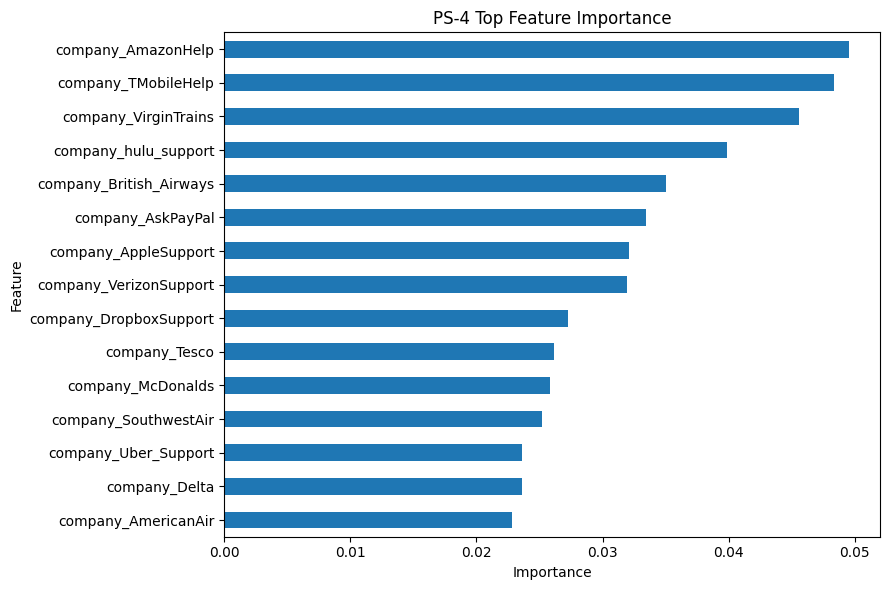


========== PS-4 ARTIFACTS ==========
Model  : ps4_xgboost_response_time_model.pkl
Bundle : ps4_xgboost_bundle.pkl
Target : log1p(response_time)

Features used:
 - message_length
 - word_count
 - hour
 - day_of_week
 - urgency
 - intent_Account Management
 - intent_Billing Issue
 - intent_Complaint
 - intent_General Inquiry
 - intent_Technical Issue
 - priority_High
 - priority_Low
 - priority_Medium
 - company_ATT
 - company_ATVIAssist
 - company_AWSSupport
 - company_AdobeCare
 - company_AirAsiaSupport
 - company_AirbnbHelp
 - company_AlaskaAir
 - company_AldiUK
 - company_AmazonHelp
 - company_AmericanAir
 - company_AppleSupport
 - company_ArbysCares
 - company_ArgosHelpers
 - company_AskAmex
 - company_AskCiti
 - company_AskDSC
 - company_AskLyft
 - company_AskPapaJohns
 - company_AskPayPal
 - company_AskPlayStation
 - company_AskRBC
 - company_AskRobinhood
 - company_AskSeagate
 - company_AskTarget
 - company_AskTigogh
 - company_AskVirginMoney
 - company_Ask_Spectrum
 - company_A

In [126]:
# ============================================================
# PS-4 — SAVE FINAL MODEL
# + PREPROCESSOR
# + FEATURE IMPORTANCE
# ============================================================

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# 1. SAVE FINAL XGBOOST MODEL
# ============================================================

joblib.dump(
    best_model,
    "ps4_xgboost_response_time_model.pkl"
)


print(
    "PS-4 XGBoost model saved successfully."
)


# ============================================================
# 2. CREATE PRODUCTION BUNDLE
# ============================================================

ps4_bundle = {

    "model": best_model,


    # Same encoder used during training
    "categorical_encoder": encoder,


    # Categorical features
    "categorical_features": [
        "intent",
        "priority",
        "company"
    ],


    # Numeric features
    "numeric_features": [
        "message_length",
        "word_count",
        "hour",
        "day_of_week",
        "urgency"
    ],


    # IMPORTANT:
    # PS-4 was trained using log1p(response_time)
    "target_transform": "log1p",


    # Maximum cleaned response time.
    # Used as a safety limit during inference.
    "target_upper_limit": float(
        y_clean.max()
    )
}


# ============================================================
# 3. SAVE BUNDLE
# ============================================================

joblib.dump(
    ps4_bundle,
    "ps4_xgboost_bundle.pkl"
)


print(
    "PS-4 preprocessing bundle saved successfully."
)


# ============================================================
# 4. FINAL MODEL METRICS
# ============================================================

print(
    "\n========== PS-4 FINAL MODEL =========="
)


print(
    "Model : XGBoost"
)


print(
    "MAE   :",
    round(
        test_mae,
        2
    ),
    "minutes"
)


print(
    "RMSE  :",
    round(
        test_rmse,
        2
    ),
    "minutes"
)


print(
    "R²    :",
    round(
        test_r2,
        4
    )
)


# ============================================================
# 5. FEATURE NAMES
# ============================================================

numeric_feature_names = [

    "message_length",

    "word_count",

    "hour",

    "day_of_week",

    "urgency"
]


categorical_feature_names = (

    encoder
    .get_feature_names_out(
        [
            "intent",
            "priority",
            "company"
        ]
    )
    .tolist()

)


feature_names = (

    numeric_feature_names

    + categorical_feature_names

)


# ============================================================
# 6. GET FEATURE IMPORTANCE
# ============================================================

importance = np.asarray(

    best_model
    .feature_importances_

)


# ============================================================
# 7. FEATURE COUNT CHECK
# ============================================================

print(
    "\n========== FEATURE COUNT CHECK =========="
)


print(
    "Model feature count :",
    len(importance)
)


print(
    "Feature-name count  :",
    len(feature_names)
)


if len(importance) != len(feature_names):

    raise ValueError(

        "PS-4 feature mismatch detected. "

        f"Model has {len(importance)} features, "

        f"but {len(feature_names)} feature names "
        "were generated."

    )


# ============================================================
# 8. FEATURE IMPORTANCE DATAFRAME
# ============================================================

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})


importance_df = (

    importance_df

    .sort_values(
        "Importance",
        ascending=False
    )

)


# ============================================================
# 9. DISPLAY TOP FEATURES
# ============================================================

print(
    "\n========== TOP PS-4 FEATURES =========="
)


print(

    importance_df
    .head(20)
    .to_string(
        index=False
    )

)


# ============================================================
# 10. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (

    importance_df

    .head(15)

    .sort_values(
        "Importance"
    )

)


top_features.plot(

    x="Feature",

    y="Importance",

    kind="barh",

    figsize=(9, 6),

    legend=False

)


plt.title(
    "PS-4 Top Feature Importance"
)


plt.xlabel(
    "Importance"
)


plt.tight_layout()


plt.show()


# ============================================================
# 11. FINAL ARTIFACT SUMMARY
# ============================================================

print(
    "\n========== PS-4 ARTIFACTS =========="
)


print(
    "Model  : ps4_xgboost_response_time_model.pkl"
)


print(
    "Bundle : ps4_xgboost_bundle.pkl"
)


print(
    "Target : log1p(response_time)"
)


print(
    "\nFeatures used:"
)


for feature in feature_names:

    print(
        " -",
        feature
    )

In [127]:
# ============================================================
# PS-4 — SAVE RESULTS
# ============================================================

ps4_final_results = pd.DataFrame({
    "Metric": ["MAE (minutes)", "RMSE (minutes)", "R²"],
    "Value": [
        mean_absolute_error(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        r2_score(y_test, test_pred)
    ]
})

print("========== PS-4 RESULTS ==========")
print(ps4_final_results.round(4))

ps4_final_results.to_csv(
    "ps4_final_results.csv",
    index=False
)

print("\nPS-4 completed successfully.")

========== PS-4 RESULTS ==========
           Metric     Value
0   MAE (minutes)  159.1127
1  RMSE (minutes)  497.3485
2              R²    0.0352

PS-4 completed successfully.


In [154]:
# ============================================================
# SAVE FINAL STREAMLIT ARTIFACTS — FIXED
# ============================================================

import joblib
import tensorflow as tf

# ---------------- PS-1 ----------------
joblib.dump(
    final_svm,
    "ps1_intent_svm_model.pkl"
)
joblib.dump(
    tfidf,
    "ps1_tfidf_vectorizer.pkl"
)

# ---------------- PS-2 ----------------
joblib.dump(
    final_svm_p2,
    "ps2_priority_svm_model.pkl"
)
joblib.dump(
    tfidf_p2,
    "ps2_priority_tfidf_vectorizer.pkl"
)

# ---------------- PS-3 ----------------
# Build inference models from the IMPROVED Seq2Seq + Attention model.
# Do not reuse the old encoder_model / decoder_model from the initial model.

encoder_model_v2 = tf.keras.Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c],
    name="PS3_Encoder_Inference"
)

decoder_token_input = tf.keras.Input(
    shape=(1,),
    dtype="int32",
    name="decoder_token_input"
)

encoder_outputs_input = tf.keras.Input(
    shape=(MAX_QUERY_LEN, LATENT_DIM),
    name="encoder_outputs_input"
)

decoder_state_h_input = tf.keras.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_h_input"
)

decoder_state_c_input = tf.keras.Input(
    shape=(LATENT_DIM,),
    name="decoder_state_c_input"
)

decoder_embedding_layer = improved_model.get_layer(
    "decoder_embedding"
)
decoder_lstm_layer = improved_model.get_layer(
    "decoder_lstm"
)
attention_layer = improved_model.get_layer(
    "attention"
)
concat_layer = improved_model.get_layer(
    "decoder_attention"
)
output_layer = improved_model.get_layer(
    "response_output"
)

decoder_embedded = decoder_embedding_layer(
    decoder_token_input
)

decoder_output, decoder_h, decoder_c = decoder_lstm_layer(
    decoder_embedded,
    initial_state=[
        decoder_state_h_input,
        decoder_state_c_input
    ]
)

attention_context = attention_layer([
    decoder_output,
    encoder_outputs_input
])

decoder_combined = concat_layer([
    decoder_output,
    attention_context
])

decoder_token_output = output_layer(
    decoder_combined
)

decoder_model_v2 = tf.keras.Model(
    [
        decoder_token_input,
        encoder_outputs_input,
        decoder_state_h_input,
        decoder_state_c_input
    ],
    [
        decoder_token_output,
        decoder_h,
        decoder_c
    ],
    name="PS3_Decoder_Inference"
)

encoder_model_v2.save("ps3_encoder.keras")
decoder_model_v2.save("ps3_decoder.keras")

joblib.dump(
    query_tokenizer_v2,
    "ps3_query_tokenizer.pkl"
)

joblib.dump(
    response_tokenizer_v2,
    "ps3_response_tokenizer.pkl"
)

joblib.dump(
    retrieval_bundle,
    "ps3_retrieval_bundle.pkl"
)

improved_model.save(
    "ps3_seq2seq_attention.keras"
)

# ---------------- PS-4 ----------------
joblib.dump(
    best_model,
    "ps4_xgboost_response_time_model.pkl"
)

joblib.dump(
    ps4_bundle,
    "ps4_xgboost_bundle.pkl"
)

print("========== ALL FINAL ARTIFACTS SAVED ==========")
print("PS-1: ps1_intent_svm_model.pkl")
print("PS-1: ps1_tfidf_vectorizer.pkl")
print("PS-2: ps2_priority_svm_model.pkl")
print("PS-2: ps2_priority_tfidf_vectorizer.pkl")
print("PS-3: ps3_encoder.keras")
print("PS-3: ps3_decoder.keras")
print("PS-3: ps3_query_tokenizer.pkl")
print("PS-3: ps3_response_tokenizer.pkl")
print("PS-4: ps4_xgboost_response_time_model.pkl")
print("PS-4: ps4_xgboost_bundle.pkl")


========== ALL FINAL ARTIFACTS SAVED ==========
PS-1: ps1_intent_svm_model.pkl
PS-1: ps1_tfidf_vectorizer.pkl
PS-2: ps2_priority_svm_model.pkl
PS-2: ps2_priority_tfidf_vectorizer.pkl
PS-3: ps3_encoder.keras
PS-3: ps3_decoder.keras
PS-3: ps3_query_tokenizer.pkl
PS-3: ps3_response_tokenizer.pkl
PS-4: ps4_xgboost_response_time_model.pkl
PS-4: ps4_xgboost_bundle.pkl


In [155]:
# Final artifact check
print("Final Streamlit artifact names:")
for name in [
    "ps1_intent_svm_model.pkl",
    "ps1_tfidf_vectorizer.pkl",
    "ps2_priority_svm_model.pkl",
    "ps2_priority_tfidf_vectorizer.pkl",
    "ps3_encoder.keras",
    "ps3_decoder.keras",
    "ps3_query_tokenizer.pkl",
    "ps3_response_tokenizer.pkl",
    "ps3_retrieval_bundle.pkl",
    "ps4_xgboost_response_time_model.pkl",
    "ps4_xgboost_bundle.pkl"
]:
    print(name)


Final Streamlit artifact names:
ps1_intent_svm_model.pkl
ps1_tfidf_vectorizer.pkl
ps2_priority_svm_model.pkl
ps2_priority_tfidf_vectorizer.pkl
ps3_encoder.keras
ps3_decoder.keras
ps3_query_tokenizer.pkl
ps3_response_tokenizer.pkl
ps3_retrieval_bundle.pkl
ps4_xgboost_response_time_model.pkl
ps4_xgboost_bundle.pkl


In [156]:
# ============================================================
# PS-3 DEBUG TEST
# ============================================================

query = "my package has not yet arrived"

raw_response = generate_response(query)

print("RAW SEQ2SEQ RESPONSE:")
print(raw_response)

print("\nQUALITY CHECK:")
print(is_poor_response(query, raw_response))

print("\nFINAL RESPONSE:")
result = get_final_response(query)

print(result)

RAW SEQ2SEQ RESPONSE:
hi there! can you please dm us your details here and we'll be happy to help.

QUALITY CHECK:
True

FINAL RESPONSE:
{'response': "please let us know if doesn't arrive by friday! we'd like to help!", 'method': 'TF-IDF Retrieval', 'similarity': 0.5079539060123796}
